# Import

In [ ]:
import warnings

import pandas as pd
import numpy as np
import optuna
import scipy
from sklearn.base import RegressorMixin, BaseEstimator
from sklearn.exceptions import NotFittedError
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler, FunctionTransformer, RobustScaler
from sklearn.feature_selection import (
    f_regression,
    mutual_info_regression
)
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import (
    IsolationForest,
    RandomForestRegressor,
    RandomForestClassifier
)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)
import seaborn as sns
from matplotlib import pyplot as plt
from xgboost import XGBRegressor

from data_files.functions import (
    stat_compare_distr,
    error_plots,
    significance_r2
)


%matplotlib inline
warnings.filterwarnings("once")

In [2]:
class BaseRegressor(RegressorMixin, BaseEstimator):

    def __init__(
            self, estimator, num_cols, cat_cols,
            need_impute=True, need_scale=True
        ):
        self.estimator = estimator
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.need_impute = need_impute
        self.need_scale = need_scale
        self._num_robust_scaler = ColumnTransformer(
            [("scaler", RobustScaler(), self.num_cols)],
            remainder="passthrough"
        )
        self._num_imputer = IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=30, max_depth=3,
                max_features=0.3, random_state=17
            ), max_iter=2,
            random_state=17, missing_values=np.nan
        )
        self._cat_predictors = {}
        self._scaler = ColumnTransformer(
            [
                ("std_scaler", StandardScaler(), [
                    col for col in self.num_cols if col in {
                        "popularity", "danceability", "energy", "loudness",
                        "valence", "tempo", "vowels_ratio", "consonants_ratio"
                    }
                ]),
                ("log_scaler", FunctionTransformer(
                    lambda x: np.log10(x + 1e-14), lambda x: np.power(10, x)
                    ), [
                    col for col in self.num_cols if col in {
                        "speechiness", "acousticness", "instrumentalness",
                        "liveness", "duration_ms", "name_len"
                    }
                ])
            ],
            remainder="passthrough"
        )
    
    def _fill_cat_missing(self, X: pd.DataFrame):
        ## fill na in cat features by random forest
        na_cat_feat = np.array(self.cat_cols)[X.loc[:, self.cat_cols].isna().any(axis=0)]
        for cat in na_cat_feat:
            missing = X.loc[:, cat].isna()
            X_train = X.loc[~missing].drop(cat, axis=1)
            X_test = X.loc[missing].drop(cat, axis=1)
            y_train = X.loc[~missing, cat]
            if str(cat) not in self._cat_predictors:
                self._cat_predictors[str(cat)] = RandomForestClassifier(
                    n_estimators=50, random_state=17,
                    max_features="sqrt", max_depth=15
                )
                self._cat_predictors[str(cat)].fit(X_train, y_train)
            X.loc[missing, cat] = self._cat_predictors[str(cat)].predict(X_test).ravel()
        return X

    def _imputing(self, X: pd.DataFrame, col_names: list[str], fit_stage: bool):
        ## fill na in cat features by random forest
        if self.cat_cols != []:
            X = self._fill_cat_missing(X)
        if fit_stage:
            ## impute continuous features
            imputed = self._num_imputer.fit_transform(
                self._num_robust_scaler.fit_transform(X)
            )
        else:
            ## impute continuous features by predefined imputer
            imputed = self._num_imputer.transform(
                self._num_robust_scaler.transform(X)
            )
        ## transformers_ is list like [(name, fitted_transformer, column), ...]
        ## inverse transform of numeric features
        imputed[:, :len(self.num_cols)] = self._num_robust_scaler.transformers_[0][1]\
                .inverse_transform(imputed[:, :len(self.num_cols)])
        imputed = pd.DataFrame(
            imputed,
            columns=list(self.num_cols) + list(self.cat_cols)
        )
        return imputed.loc[:, col_names]
    
    def _scaling(self, X: pd.DataFrame, col_names: list[str], fit_stage: bool):
        if fit_stage:
            scaled = pd.DataFrame(
                self._scaler.fit_transform(X),
                columns=[
                        col for col in self.num_cols if col in {
                            "popularity", "danceability", "energy", "loudness",
                            "valence", "tempo", "vowels_ratio", "consonants_ratio"
                        }
                ] + [
                        col for col in self.num_cols if col in {
                            "speechiness", "acousticness", "instrumentalness",
                            "liveness", "duration_ms", "name_len"
                        }
                ] +  list(self.cat_cols)
            )
            return scaled.loc[:, col_names]
        scaled = pd.DataFrame(
            self._scaler.transform(X),
            columns=[
                    col for col in self.num_cols if col in {
                        "popularity", "danceability", "energy", "loudness",
                        "valence", "tempo", "vowels_ratio", "consonants_ratio"
                    }
            ] + [
                    col for col in self.num_cols if col in {
                        "speechiness", "acousticness", "instrumentalness",
                        "liveness", "duration_ms", "name_len"
                    }
            ] +  list(self.cat_cols)
        )
        return scaled.loc[:, col_names]
    
    def fit(self, X: pd.DataFrame, y: pd.Series | pd.DataFrame | None=None):
        if self.cat_cols is None:
            self.cat_cols = []
        else:
            self.cat_cols = [str(col) for col in self.cat_cols]
        self.num_cols = [str(col) for col in self.num_cols]
        col_names = X.columns.to_list()
        X_copy = X.copy(deep=True)
        if self.need_impute:
            X_copy = self._imputing(X_copy, col_names, True)
        
        if self.need_scale:
            X_copy = self._scaling(X_copy, col_names, True)

        self.estimator.fit(X_copy, y)
        self._is_fitted = True
        return self
    
    def predict(self, X: pd.DataFrame):
        if not hasattr(self, "_is_fitted") or not self._is_fitted:
            raise NotFittedError("BaseRegressor is not fitted yet")
        col_names = X.columns.to_list()
        if self.need_impute:
            X = self._imputing(X,  col_names=col_names, fit_stage=False)
        if self.need_scale:
            X = self._scaling(X, col_names, False)

        return self.estimator.predict(X)
    
    def __sklearn_is_fitted__(self):
        """
        Check fitted status and return a Boolean value.
        """
        return hasattr(self, "_is_fitted") and self._is_fitted


In [11]:
def cv_fit(
        model, grid_param: dict, x_train: pd.DataFrame,
        y_train: pd.DataFrame, numeric_cols: list[str],
        categ_cols: list[str], n_trials: int=100
):
    """
    Cross val parameter search. Score metric is RMSE
    
    Args:
        model (any):
            Estimator like XGBRegressor, LinearRegression, etc.
        grid_param (dict[str, list]):
            Grid of parameters like {param_name: ["type", lower, upper]}.
            Type is kind of instance like 'int', 'float', 'categ'.
            If type is 'categ', trial used all values followed by "type".
        x_train (pd.DataFrame):
            Features
        y_train (pd.DataFrame | pd.Sereis):
            Targets
        numeric_cols (list[str]):
            Name of numeric columns
        categ_cols (list[str]):
            Names of categorical columns
        n_trials (int):
            Number of trials for optuna optimizer
    """

    def objective(trial):
        nonlocal grid_param, x_train, y_train, numeric_cols, categ_cols, model
        params = {}
        for key, val in grid_param.items():
            match val[0]:
                case "int":
                    params[key] = trial.suggest_int(key, val[1], val[2])
                case "float":
                    params[key] = trial.suggest_float(key, val[1], val[2])
                case "categ":
                    params[key] = trial.suggest_categorical(key, val[1:])
        estimator = BaseRegressor(
            model.set_params(**params), numeric_cols,
            categ_cols
        )
        return cross_val_score(
            estimator, x_train, y_train,
            scoring="neg_root_mean_squared_error",
            cv=4, n_jobs=-1, error_score="raise"
        ).mean() * -1

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials)
    print("best params\n", study.best_params)
    print(
        f"CV RMSE: {study.best_trial.value:.5f}",
        sep="\n"
    )

# Exploration analysis

## Basic info

In [23]:
df = pd.read_csv("data_files/train.csv")
df.rename(columns={
    "Artist Name": "artist", "Track Name": "track",
    "Popularity": "popularity", "duration_in min/ms": "duration_ms",
    "Class": "class"
}, inplace=True)

In [24]:
# get categorical columns
categ_col = [col for col in df.columns if df.loc[:, col].nunique() < 50]
print("categorical columns", categ_col)
for col in categ_col:
    df[col] = pd.Categorical(df.loc[:, col])

categorical columns ['key', 'mode', 'time_signature', 'class']


In [25]:
# each column has appropriate dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   artist            17996 non-null  object  
 1   track             17996 non-null  object  
 2   popularity        17568 non-null  float64 
 3   danceability      17996 non-null  float64 
 4   energy            17996 non-null  float64 
 5   key               15982 non-null  category
 6   loudness          17996 non-null  float64 
 7   mode              17996 non-null  category
 8   speechiness       17996 non-null  float64 
 9   acousticness      17996 non-null  float64 
 10  instrumentalness  13619 non-null  float64 
 11  liveness          17996 non-null  float64 
 12  valence           17996 non-null  float64 
 13  tempo             17996 non-null  float64 
 14  duration_ms       17996 non-null  float64 
 15  time_signature    17996 non-null  category
 16  class             1799

In [26]:
# min duration_ms is too small, lower than 0
df.drop("popularity", axis=1).iloc[:, :10].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness
count,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,13619.000000
mean,0.543433,0.662777,-7.910660,0.079707,0.247082,0.177562
std,0.166268,0.235373,4.049151,0.083576,0.310632,0.304048
min,0.059600,0.000020,-39.952000,0.022500,0.000000,0.000001
25%,0.432000,0.509000,-9.538000,0.034800,0.004300,0.000089
50%,0.545000,0.700000,-7.016000,0.047400,0.081400,0.003910
75%,0.659000,0.860000,-5.189000,0.083000,0.434000,0.200000
max,0.989000,1.000000,1.355000,0.955000,0.996000,0.996000


In [27]:
df.drop("popularity", axis=1).iloc[:, 10:].describe()

,liveness,valence,tempo,duration_ms
count,17996.000000,17996.000000,17996.000000,1.799600e+04
mean,0.196170,0.486208,122.623294,2.007445e+05
std,0.159212,0.240195,29.571527,1.119891e+05
min,0.011900,0.018300,30.557000,5.016500e-01
25%,0.097500,0.297000,99.620750,1.663370e+05
50%,0.129000,0.481000,120.065500,2.091600e+05
75%,0.258000,0.672000,141.969250,2.524900e+05
max,1.000000,0.986000,217.416000,1.477187e+06


In [28]:
# convert duration in minutes to duration in ms
df.loc[df.loc[:, "duration_ms"] < 1e2, "duration_ms"] *= 6e4
df.loc[:, ["duration_ms"]].describe()

,duration_ms
count,1.799600e+04
mean,2.358233e+05
std,8.567503e+04
min,2.332000e+04
25%,1.876497e+05
50%,2.200000e+05
75%,2.630822e+05
max,1.793160e+06


In [13]:
# track may contains non latin letters
df.sample(5)

,artist,track,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,class
5176,Latto,On God,54.0,0.905,0.528,1.0,-5.116,1,0.0721,0.351000,NaN,0.1490,0.1790,105.990,113238.0,4,5
12825,Miranda Lambert,Holding On to You,51.0,0.491,0.352,NaN,-9.856,1,0.0426,0.388000,0.000006,0.1030,0.3250,188.861,272640.0,3,4
17906,Omer Adam,◊™◊¢◊©◊ô ◊ú◊ô ◊ê◊™ ◊ñ◊î ◊ß◊©◊î,27.0,0.613,0.865,NaN,-2.925,1,0.0857,0.242000,NaN,0.1810,0.8250,180.141,190560.0,4,9
5480,Frameworks,Cusp - Edit,37.0,0.733,0.726,5.0,-9.894,0,0.0366,0.278000,0.830000,0.1730,0.0823,117.991,249080.0,4,1
9407,Wooden Shjips,Everybody Knows,38.0,0.352,0.621,2.0,-9.036,1,0.0330,0.000114,0.855000,0.0974,0.2180,123.817,318560.0,4,6


## Remove uninformative column

In [29]:
# track should be deleted because it has too many unique values
df.loc[:, ["artist", "track"]].nunique()

artist     9149
track     15129
dtype: int64

In [30]:
df = df.drop("track", axis=1)

## Check duplicated records

In [32]:
# there are duplicated records
# interestingly that duplicated records have differente class
df.loc[df.drop(columns="class", axis=1).duplicated(keep=False)]\
    .sort_values(["artist", "popularity"])\
        .loc[:, ["artist", "popularity", "time_signature", "class"]]

,artist,popularity,time_signature,class
1541,'68,36.0,4,1
9110,'68,36.0,4,6
14069,'68,36.0,4,10
6209,*repeat repeat,23.0,4,10
10838,*repeat repeat,23.0,4,1
...,...,...,...,...
16390,young friend,58.0,4,6
6535,◊©◊ù ◊ò◊ï◊ë ◊î◊ê◊ë◊ô,46.0,4,9
7415,◊©◊ù ◊ò◊ï◊ë ◊î◊ê◊ë◊ô,46.0,4,5
1543,◊ê◊ë◊ô◊ë ◊û◊ê◊®◊ß,4.0,4,6


In [33]:
# 1743 duplicated records
sum(df.drop("class", axis=1).duplicated(keep="first"))

1743

In [34]:
df = df.loc[~df.drop("class", axis=1).duplicated(keep="first")]

## Check missing values

In [35]:
# deletion of 25% rows is impracticable
df.isna().sum() / df.shape[0] * 100 // 1

artist               0.0
popularity           2.0
danceability         0.0
energy               0.0
key                 11.0
loudness             0.0
mode                 0.0
speechiness          0.0
acousticness         0.0
instrumentalness    25.0
liveness             0.0
valence              0.0
tempo                0.0
duration_ms          0.0
time_signature       0.0
class                0.0
dtype: float64

In [36]:
df = df.loc[df["popularity"].notna()]

In [37]:
# deletion of 25% rows is impracticable
df.isna().sum() / df.shape[0] * 100 // 1

artist               0.0
popularity           0.0
danceability         0.0
energy               0.0
key                 11.0
loudness             0.0
mode                 0.0
speechiness          0.0
acousticness         0.0
instrumentalness    24.0
liveness             0.0
valence              0.0
tempo                0.0
duration_ms          0.0
time_signature       0.0
class                0.0
dtype: float64

## Feature extraction

In [38]:
# since artist has string type and particular name
# is not valuable, so it's necessary to map artist name
# to numeric features
df.loc[:, "name_len"] = df.loc[:, "artist"].apply(lambda x: len(x))
df.loc[:, "vowels_ratio"] = df.loc[:, "artist"].apply(
    lambda x: sum(map(x.lower().count, "aeuio")) / len(x)
)
df.loc[:, "consonants_ratio"] = df.loc[:, "artist"].apply(
    lambda x: sum(map(x.lower().count, "qwrtpsdfgjklmnzxcvbny")) / len(x)
)

In [40]:
df.drop("artist", axis=1, inplace=True)

## Visualization

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    df.drop("popularity", axis=1), df.loc[:, "popularity"], test_size=0.2,
    random_state=17, shuffle=True
)
numeric_cols = ['danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms',
 'name_len',
 'vowels_ratio',
 'consonants_ratio']
categ_cols = ['key', 'mode', 'time_signature', 'class']

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


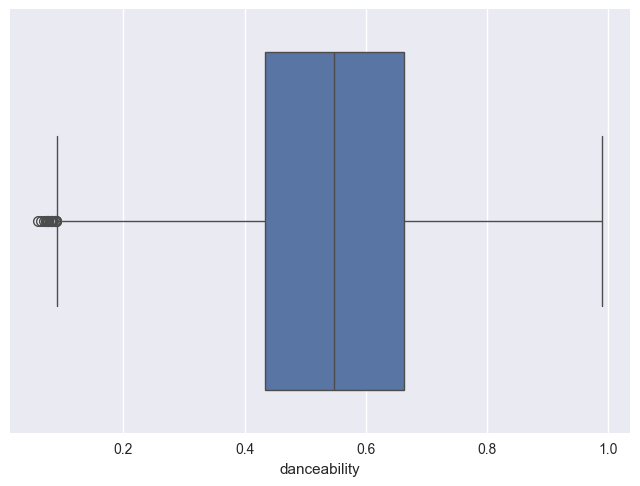

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


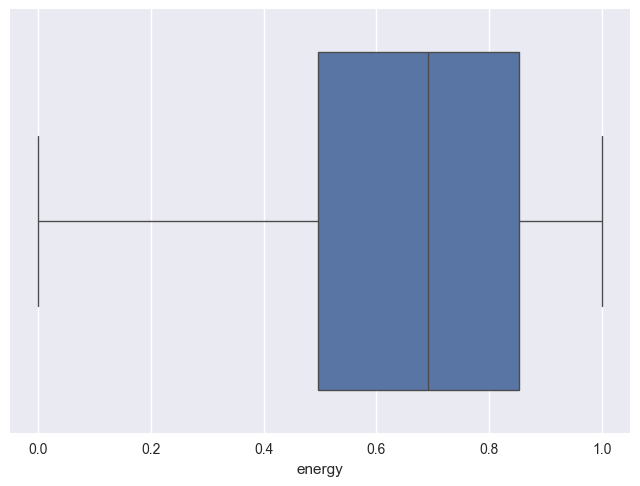

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


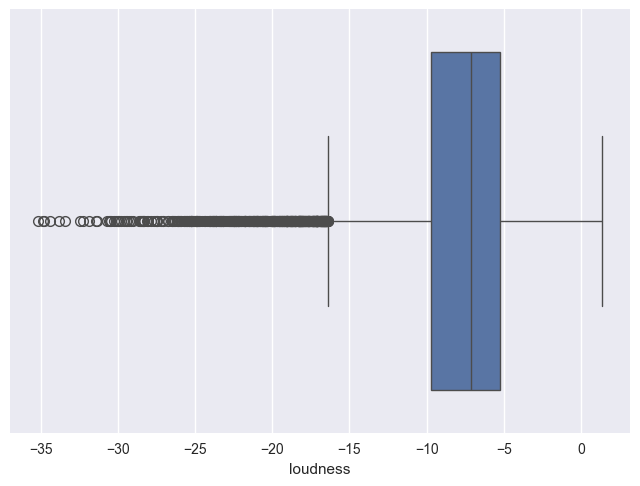

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


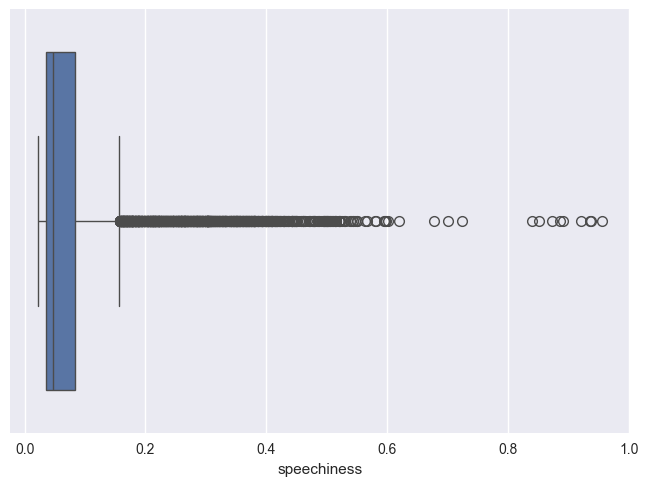

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


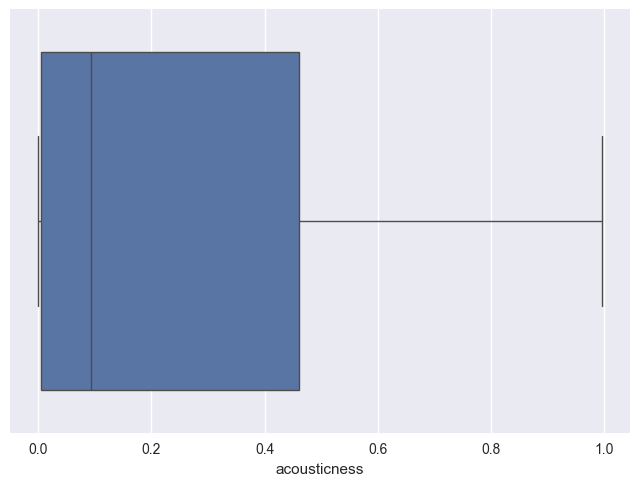

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


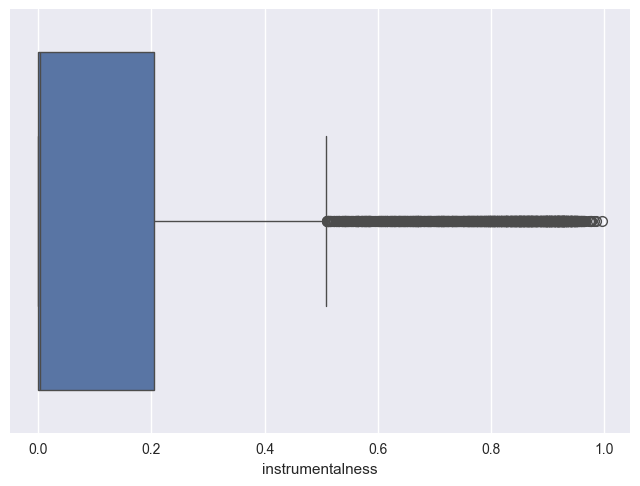

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


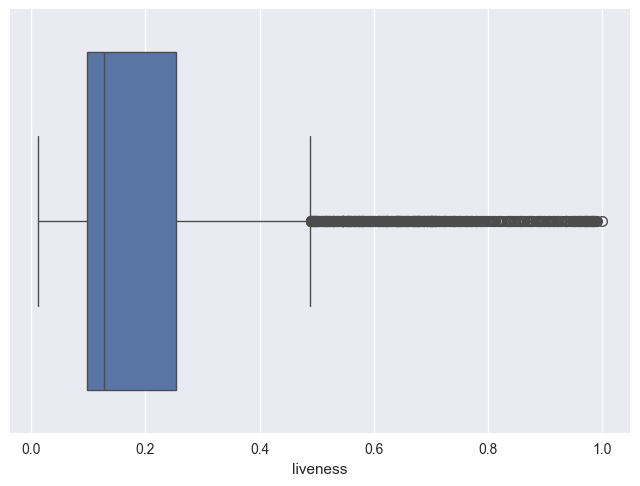

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


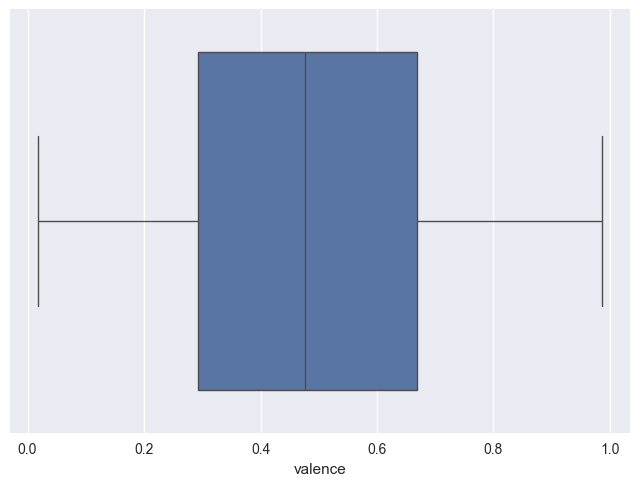

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


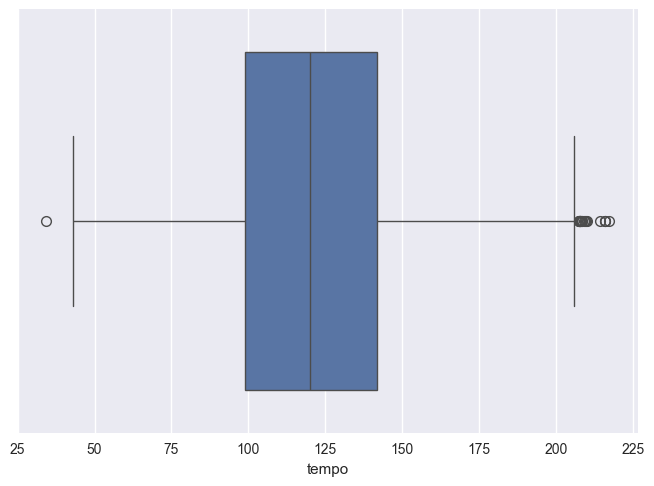

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


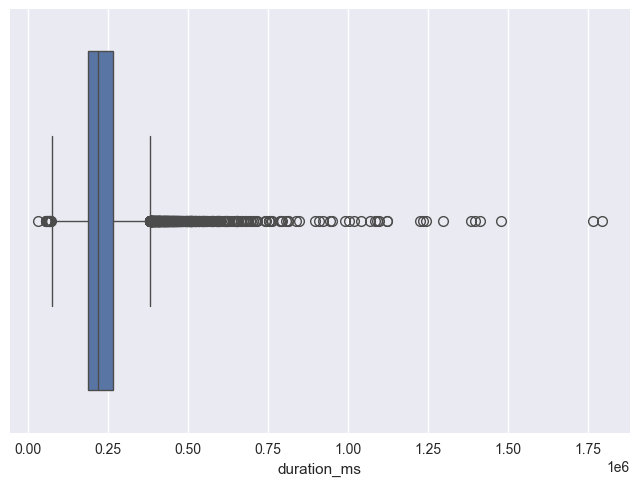

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


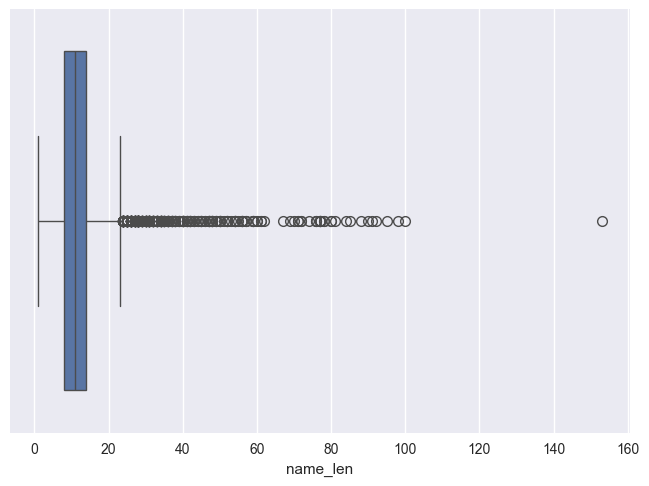

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


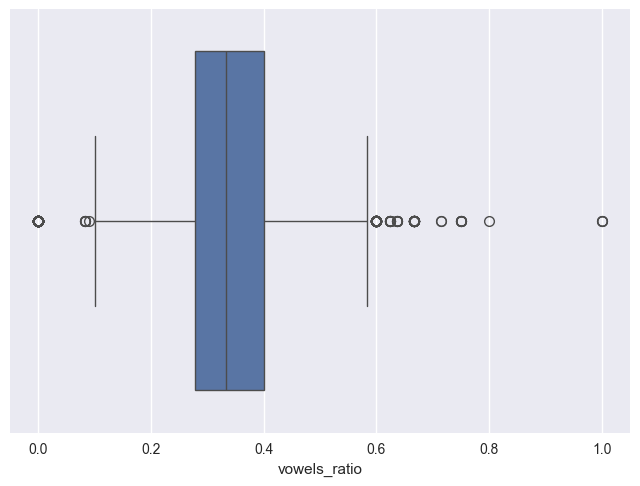

c:\Users\lev-m\source\music_classification\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


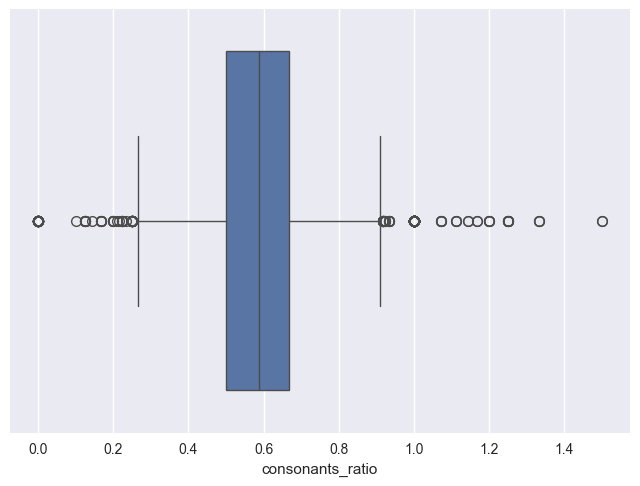

In [45]:
# there is features with skewness,
# it's probably worth to remove anomalies
with plt.style.context("seaborn-v0_8"):
    for col in numeric_cols:
        sns.boxplot(x=x_train.loc[:, col])
        plt.show();

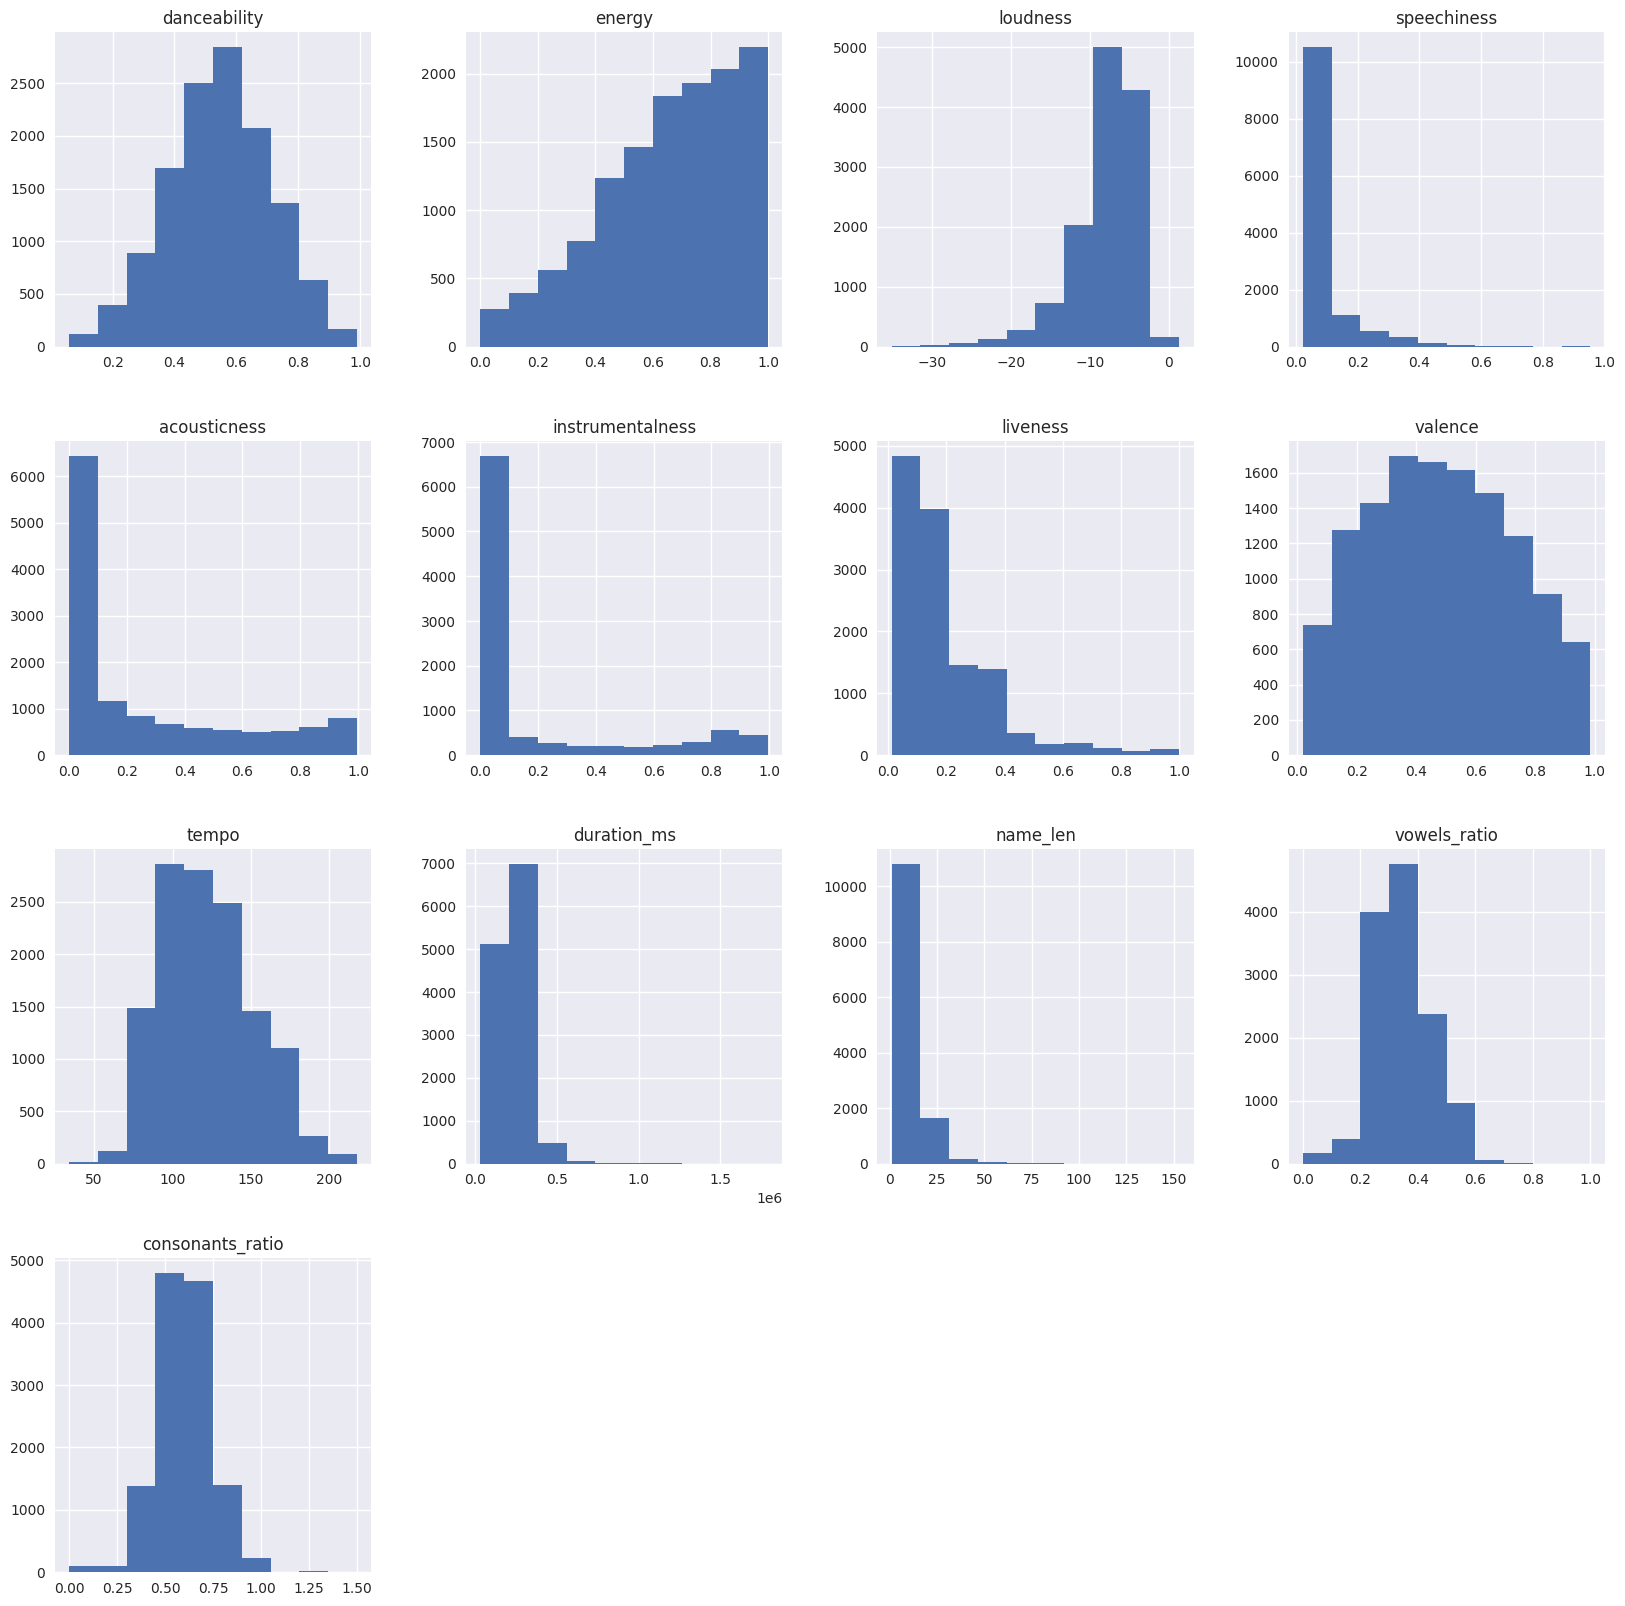

In [ ]:
# for danceability, energy, loudness,
# valence, tempo, vowels_ratio, consonants_ratio - StandardScaler

# for speechiness, acousticness, instrumentalness,
# liveness, duration_ms, name_len - logscale
with plt.style.context("seaborn-v0_8"):
    x_train.hist(figsize=(20, 20))

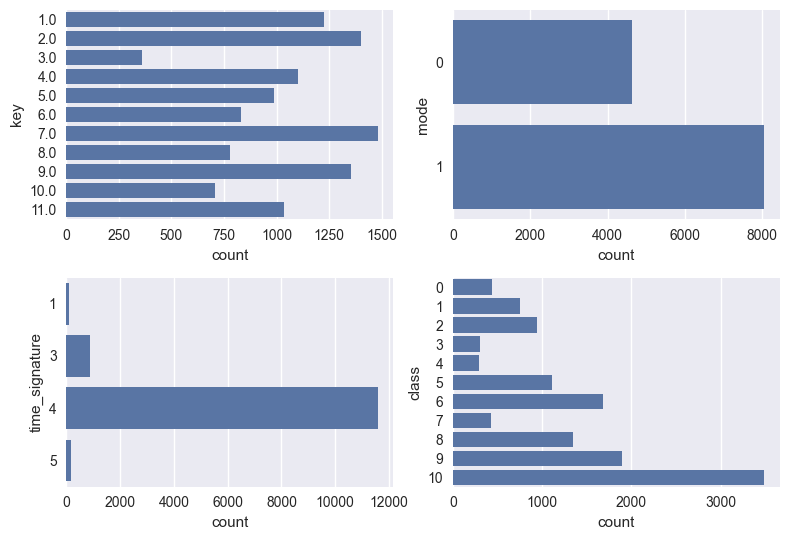

In [48]:
with plt.style.context("seaborn-v0_8"):
    _, axs = plt.subplots(2, 2)
    for i, col in enumerate(categ_cols):
        sns.countplot(x_train.loc[:, col], ax=axs[0 if i < 2 else 1, i % 2])
    plt.tight_layout()
    plt.show();

<Axes: >

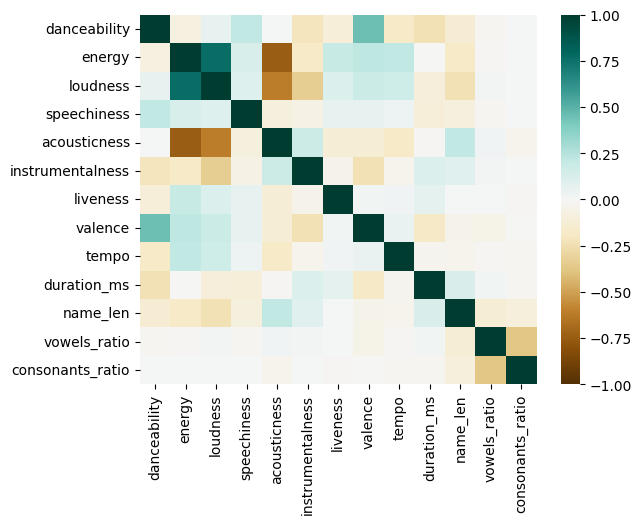

In [49]:
# there are linearly correlated features such
# as acousticness/energy, loudness/energy, acousticness/loudness.
sns.heatmap(
    x_train.loc[:, numeric_cols].corr(),
    cmap="BrBG", vmin=-1.
)

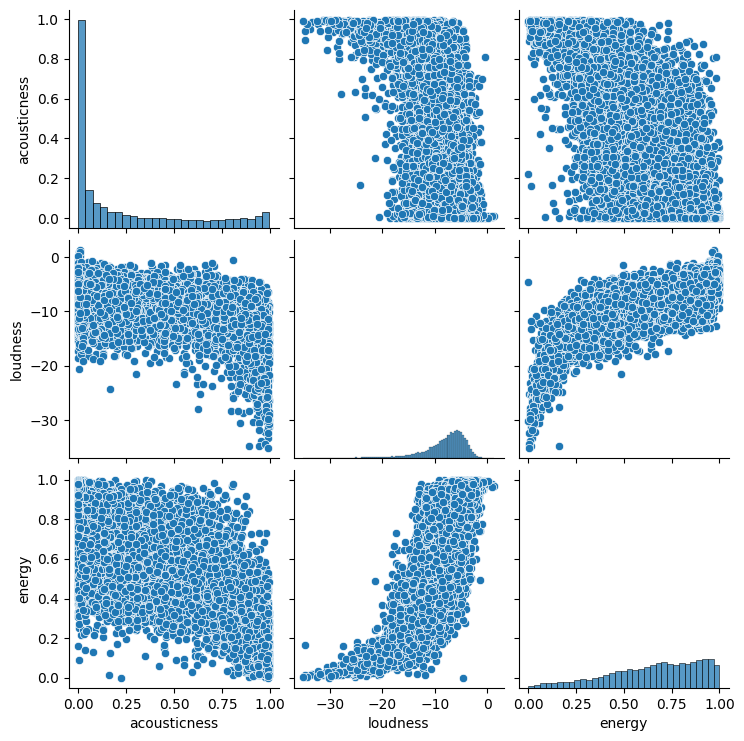

In [51]:
# loudness and acousticness distribution has linear dependency
# may be nonlinear such as logarithmic
sns.pairplot(x_train.loc[:, ["acousticness", "loudness", "energy"]])

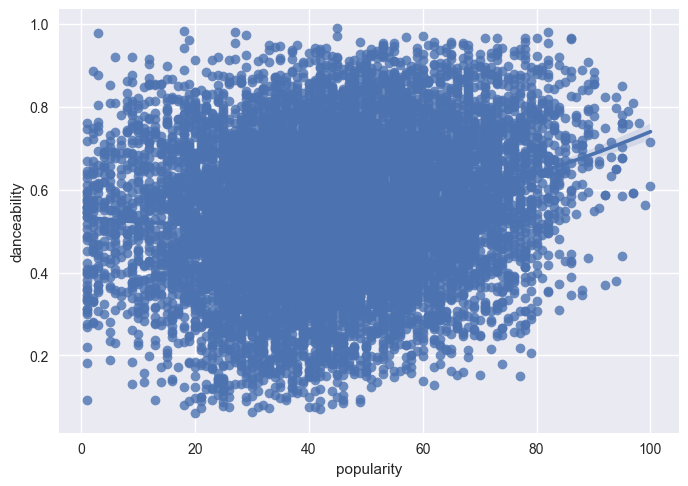

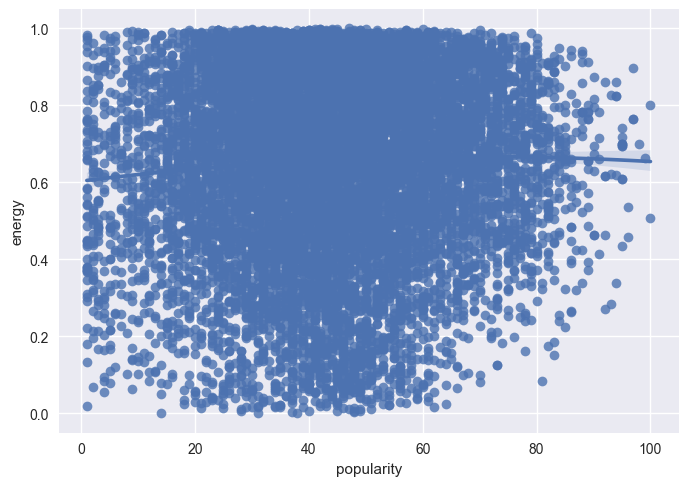

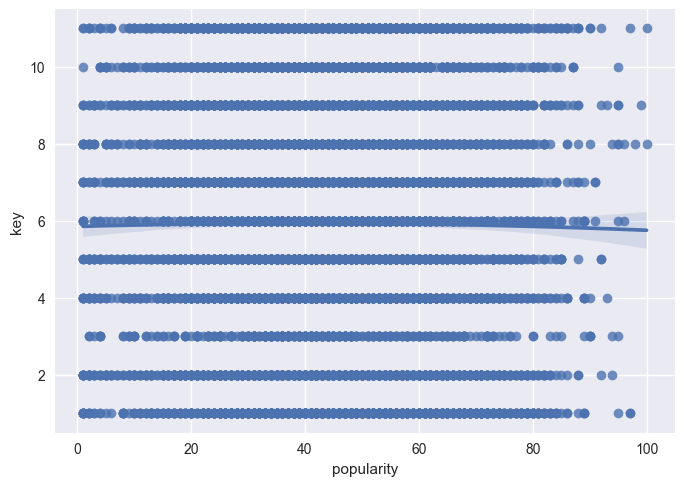

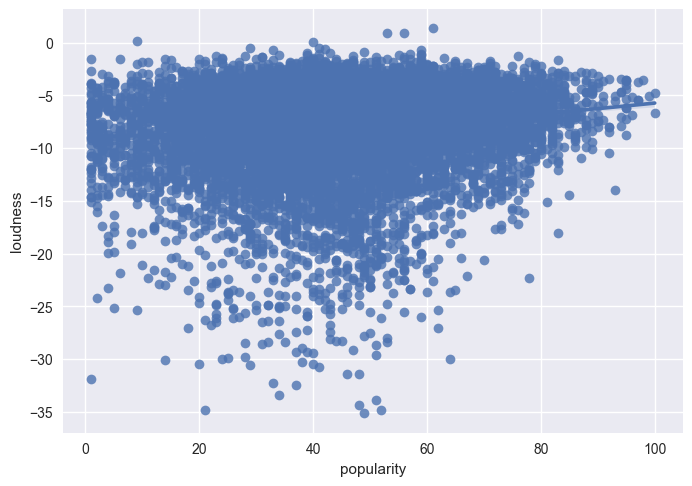

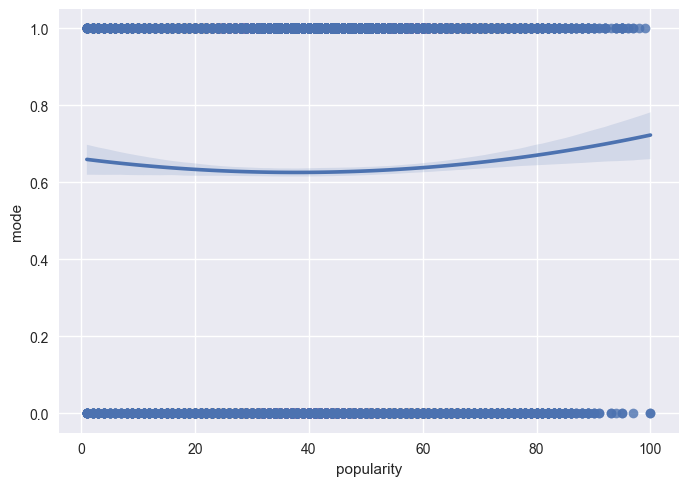

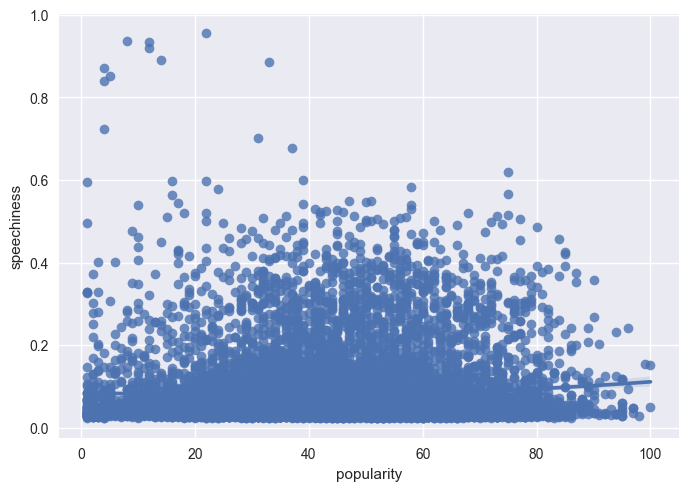

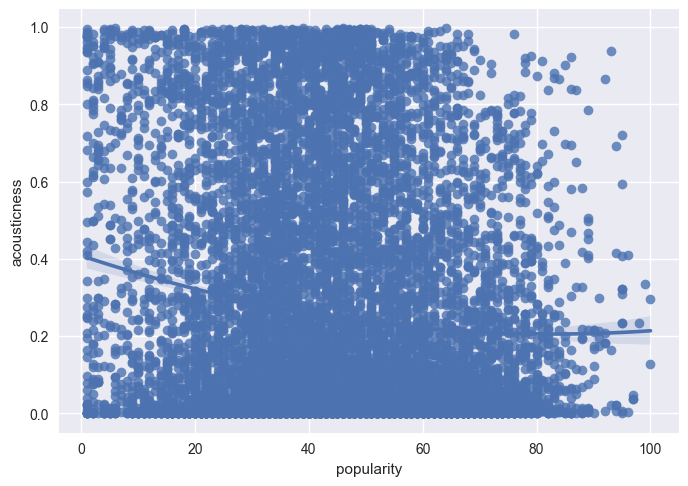

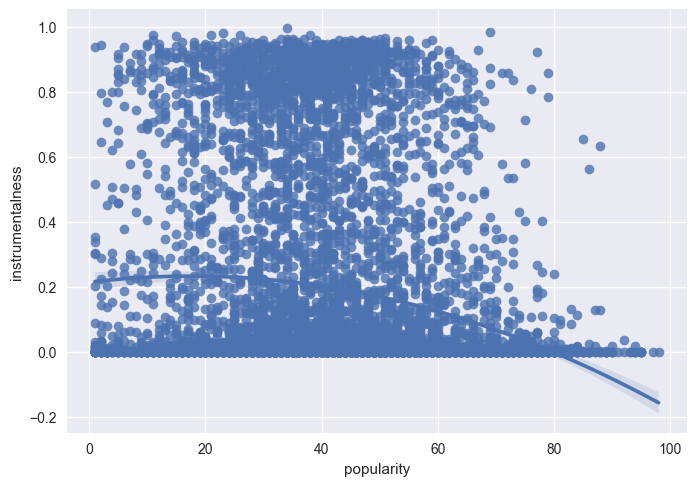

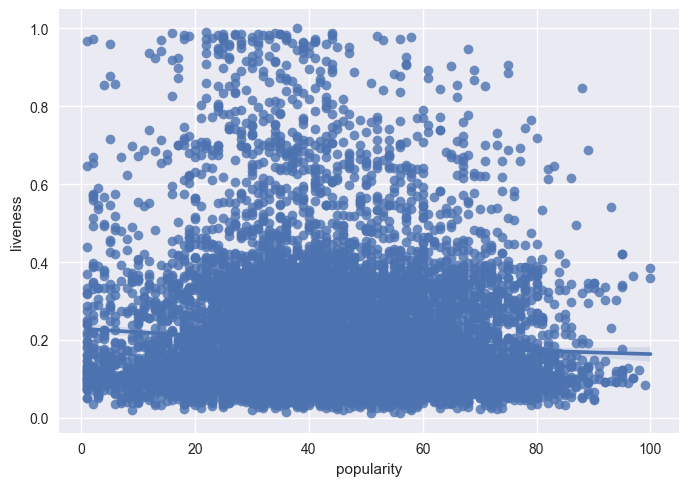

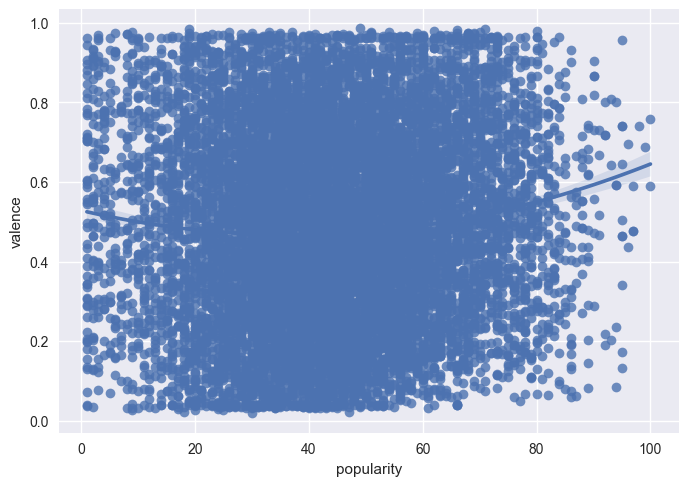

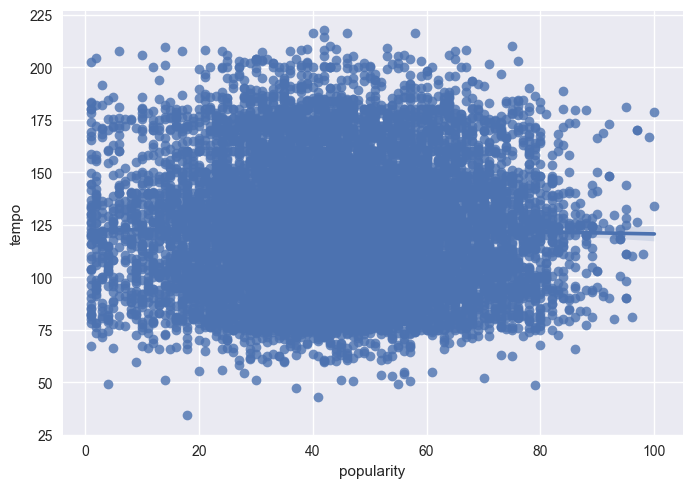

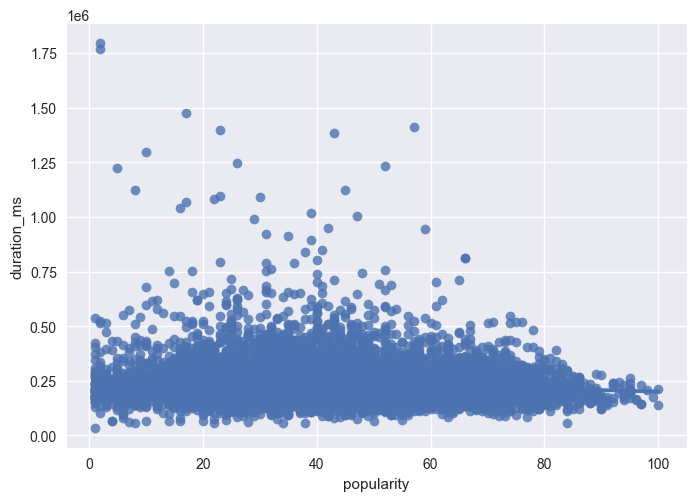

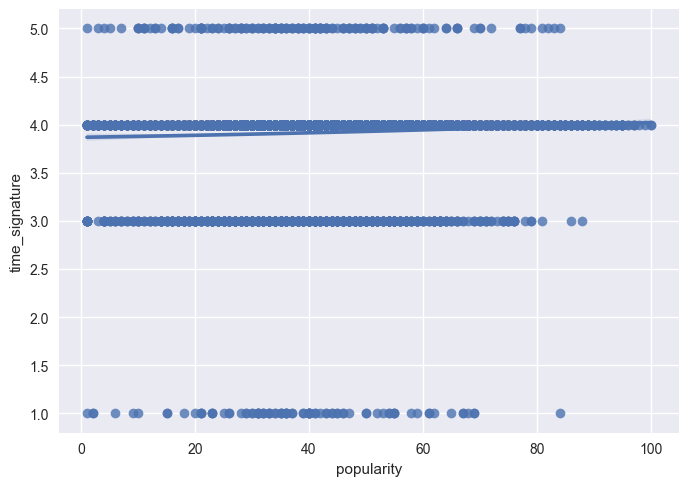

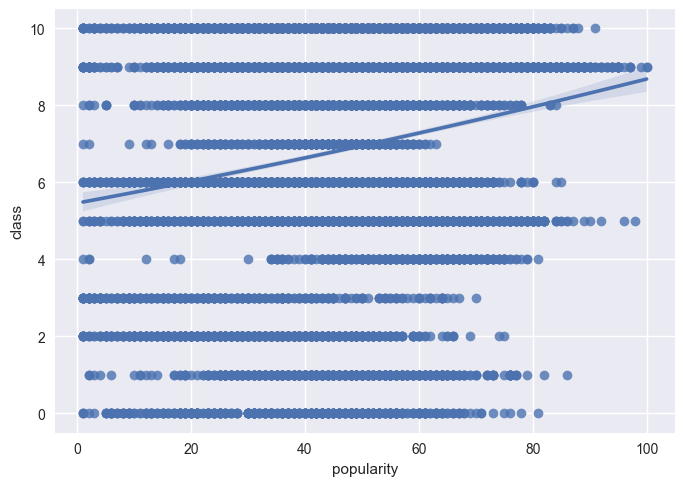

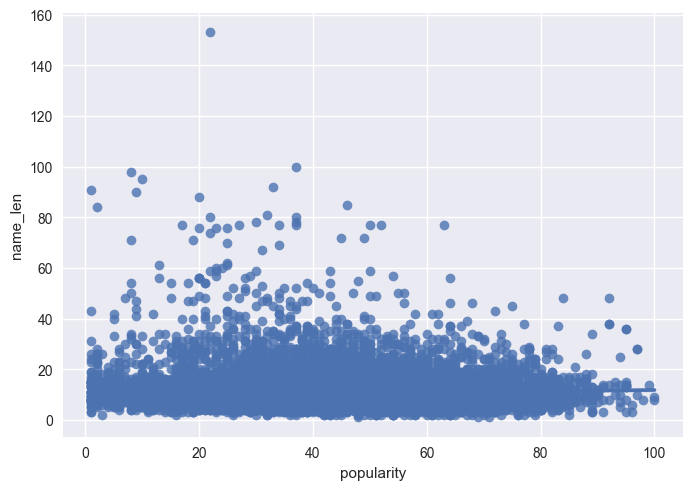

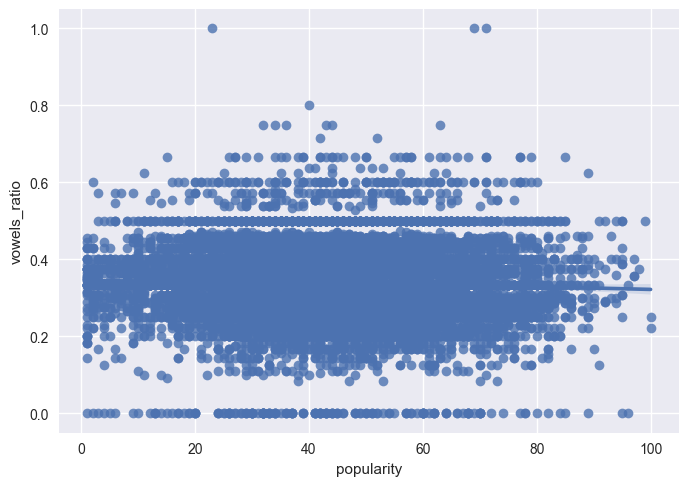

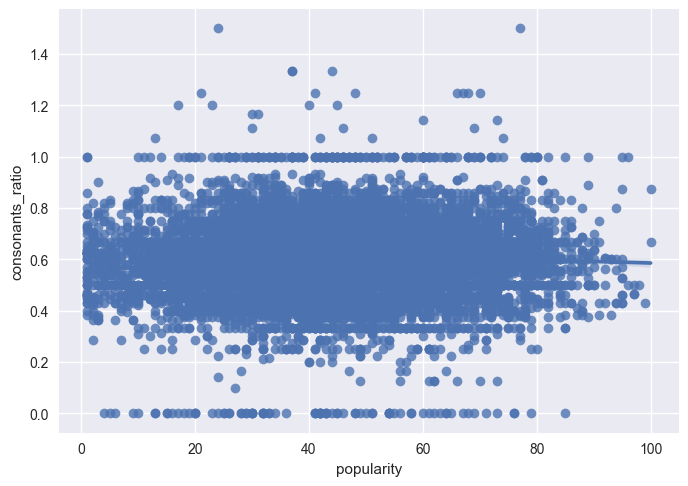

In [ ]:
# it's difficult to underline strong dependence between
# feature and popularity
with plt.style.context("seaborn-v0_8"):
    for col in x_train.columns:
        if col in categ_cols:
            sns.regplot(x=y_train, y=x_train.loc[:, col].cat.as_ordered(), order=2)
        else:
            sns.regplot(x=y_train, y=x_train.loc[:, col], order=2)
        plt.show();

## Feature selection

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    df.drop(["popularity"], axis=1), df.loc[:, "popularity"], test_size=0.2,
    random_state=17, shuffle=True
)
numeric_cols = ['danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms',
 'name_len',
 'vowels_ratio',
 'consonants_ratio']
categ_cols = ['key', 'mode', 'time_signature', 'class']

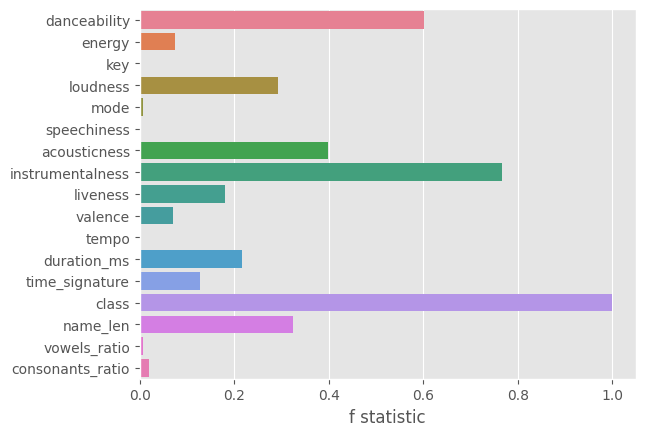

In [55]:
# remove energy, key, mode, speechiness, liveness, valence, tempo,
# time_signature, vowels_ratio, consonats_ratio
mask = x_train.notna().all(axis=1)
f_stat, p_val = f_regression(x_train.loc[mask], y_train.loc[mask])
f_stat /= np.max(f_stat)
with plt.style.context("ggplot"):
    sns.barplot(
        y=x_train.columns.to_list(), x=f_stat,
        hue=x_train.columns.to_list(),
        orient="y", palette="husl",
        legend=False
    )
    plt.xlabel("f statistic")
    plt.show();

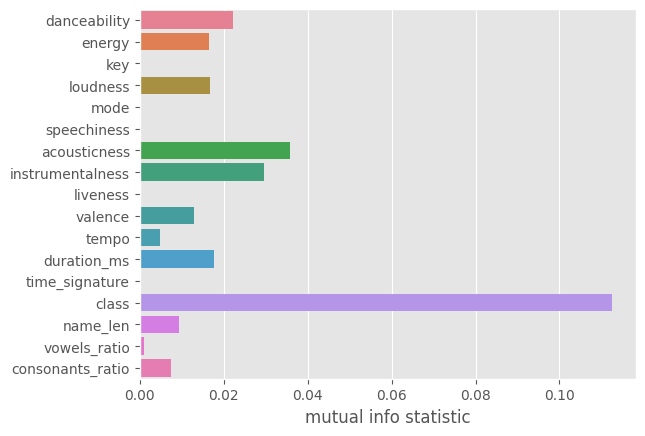

In [ ]:
# analogous results to deletion uninformative columns
mask = x_train.notna().all(axis=1)
mi_stat = mutual_info_regression(
    x_train.loc[mask], y_train.loc[mask],
    n_neighbors=7, random_state=17
)
with plt.style.context("ggplot"):
    sns.barplot(
        y=x_train.columns.to_list(), x=mi_stat,
        hue=x_train.columns.to_list(),
        orient="y", palette="husl",
        legend=False
    )
    plt.xlabel("mutual info statistic")
    plt.show();

## Remove uninformative columns

In [57]:
df.drop(columns=[
    "energy", "key", "mode", "speechiness",
    "liveness", "valence", "tempo",
    "time_signature", "vowels_ratio",
    "consonants_ratio"
]).to_csv("data_files/preprocessed_regression.csv", index=False)

# Train models

In [8]:
# split data into train val and test folds with ratio 80:20
df = pd.read_csv("data_files/preprocessed_regression.csv")
numeric_cols = [
    'danceability', 'loudness', 'acousticness',
    'instrumentalness', 'duration_ms',
    'name_len'
]
categ_cols = ['class']
for col in categ_cols:
    df[col] = pd.Categorical(df.loc[:, col])
x_train, x_test, y_train, y_test = train_test_split(
    df.drop("popularity", axis=1),
    df.loc[:, "popularity"], test_size=0.2,
    random_state=17, shuffle=True
)
iforest = IsolationForest(
    n_estimators=400, contamination=0.003, random_state=17
)
is_normal = iforest.fit_predict(x_train) == 1
x_train = x_train.loc[is_normal]
y_train = y_train.loc[is_normal]

In [ ]:
cv_fit(
    Lasso(max_iter=2000, random_state=17),
    {"alpha": ["float", 1e-6, 3.]},
    x_train, y_train, numeric_cols, categ_cols
)

[I 2025-12-19 18:00:07,242] A new study created in memory with name: no-name-b202e969-a49d-48d9-a96d-bc8b15b876d4
[I 2025-12-19 18:00:42,764] Trial 0 finished with value: 16.822341205155148 and parameters: {'alpha': 0.7809705590065271}. Best is trial 0 with value: 16.822341205155148.
[I 2025-12-19 18:00:48,890] Trial 1 finished with value: 16.873999608543446 and parameters: {'alpha': 1.1987458550171257}. Best is trial 0 with value: 16.822341205155148.
[I 2025-12-19 18:00:53,736] Trial 2 finished with value: 16.971988750650183 and parameters: {'alpha': 1.911989165290535}. Best is trial 0 with value: 16.822341205155148.
[I 2025-12-19 18:00:57,736] Trial 3 finished with value: 16.75745628541474 and parameters: {'alpha': 0.004162112531342837}. Best is trial 3 with value: 16.75745628541474.
[I 2025-12-19 18:01:01,763] Trial 4 finished with value: 16.821872373190597 and parameters: {'alpha': 0.7761582845417763}. Best is trial 3 with value: 16.75745628541474.
[I 2025-12-19 18:01:05,866] Trial

best params
 {'alpha': 0.001003046168305885}
CV RMSE: 16.75740


In [83]:
round(cross_val_score(
    BaseRegressor(LinearRegression(), numeric_cols, categ_cols),
    x_train, y_train,
    cv=4, scoring="neg_root_mean_squared_error"
).mean() * -1, 5)

np.float64(16.75739)

In [ ]:
cv_fit(
    Ridge(random_state=17),
    {"alpha": ["float", 1e-5, 10.]},
    x_train, y_train, numeric_cols, categ_cols
)

[I 2025-12-19 18:34:02,574] A new study created in memory with name: no-name-efd6034d-9eb0-4584-ac65-8984daba8930
[I 2025-12-19 18:34:17,943] Trial 0 finished with value: 16.757339517291967 and parameters: {'alpha': 3.515601024231767}. Best is trial 0 with value: 16.757339517291967.
[I 2025-12-19 18:34:23,382] Trial 1 finished with value: 16.75736886486471 and parameters: {'alpha': 1.4196029441707219}. Best is trial 0 with value: 16.757339517291967.
[I 2025-12-19 18:34:33,272] Trial 2 finished with value: 16.757307515157624 and parameters: {'alpha': 7.2587022107654215}. Best is trial 2 with value: 16.757307515157624.
[I 2025-12-19 18:34:38,144] Trial 3 finished with value: 16.757350471176398 and parameters: {'alpha': 2.6584139863465426}. Best is trial 2 with value: 16.757307515157624.
[I 2025-12-19 18:34:42,506] Trial 4 finished with value: 16.757362045390707 and parameters: {'alpha': 1.8551556923568848}. Best is trial 2 with value: 16.757307515157624.
[I 2025-12-19 18:34:47,071] Trial

best params
 {'alpha': 9.997796050644496}
CV RMSE: 16.75730


In [ ]:
cv_fit(
    RandomForestRegressor(n_estimators=300, random_state=17),
    {
        "criterion": ["categ", "poisson", "squared_error", "absolute_error", "friedman_mse"],
        "min_samples_leaf": ["int", 1, 7],
        "max_features": ["categ", "sqrt", "log2", 0.3, 0.7]
    },
    x_train, y_train, numeric_cols, categ_cols
)
# RMSE 15.636863739432645
# {'criterion': 'absolute_error', 'min_samples_leaf': 3, 'max_features': 0.7}

In [ ]:
cv_fit(
    XGBRegressor(tree_method="hist", random_state=17),
    {
        "n_estimators": ["int", 30, 300],
        "max_depth": ["int", 1, 10],
        "learning_rate": ["float", 0.01, 2.],
        "gamma": ["float", 0., 0.9],
        "colsample_bytree": ["float", 0.3, 1.],
        "reg_alpha": ["float", 0., 2.],
        "reg_lambda": ["float", 0.01, 2.]
    },
    x_train, y_train, numeric_cols, categ_cols,
    n_trials=400
)
# n_trials = 100
# {'n_estimators': 127, 'max_depth': 8, 'learning_rate': 0.04768203764287652, 'gamma': 0.8808047651146305, 'colsample_bytree': 0.8076105548529321, 'reg_alpha': 1.1873364286992847, 'reg_lambda': 1.388061903837533}
# CV RMSE: 15.68619

# Validate

In [119]:
df = pd.read_csv("data_files/preprocessed_regression.csv")
numeric_cols = [
    'danceability', 'loudness', 'acousticness',
    'instrumentalness', 'duration_ms',
    'name_len'
]
categ_cols = ['class']
for col in categ_cols:
    df[col] = pd.Categorical(df.loc[:, col])
x_train, x_val, y_train, y_val = train_test_split(
    df.drop("popularity", axis=1),
    df.loc[:, "popularity"], test_size=0.2,
    random_state=17, shuffle=True
)
iforest = IsolationForest(
    n_estimators=400, contamination=0.003, random_state=17
)
is_normal = iforest.fit_predict(x_train) == 1
x_train = x_train.loc[is_normal]
y_train = y_train.loc[is_normal]
preds = {}
models = {
    "LinearRegression": BaseRegressor(
        LinearRegression(),
        numeric_cols, categ_cols
    ),
    "Lasso": BaseRegressor(
        Lasso(max_iter=2000, random_state=17, alpha=0.001003046168305885),
        numeric_cols, categ_cols
    ),
    "Ridge": BaseRegressor(
        Ridge(random_state=17, alpha=10),
        numeric_cols, categ_cols
    ),
    "RandomForest": BaseRegressor(
        RandomForestRegressor(
            random_state=17, n_estimators=300
        ).set_params(**{
            'criterion': 'absolute_error', 'min_samples_leaf': 3,
            'max_features': 0.7
        }),
        numeric_cols, categ_cols,
    ),
    "XGBoost": BaseRegressor(
        XGBRegressor(random_state=17).set_params(**{
            'n_estimators': 127, 'max_depth': 8,
            'learning_rate': 0.04768203764287652,
            'gamma': 0.8808047651146305,
            'colsample_bytree': 0.8076105548529321,
            'reg_alpha': 1.1873364286992847,
            'reg_lambda': 1.388061903837533
        }),
        numeric_cols, categ_cols
    )
}
metrics = pd.DataFrame(columns=["model", "RMSE", "MAE", "R2"])
preds = {}
for model in models:
    models[model].fit(x_train, y_train)
    preds[model] = models[model].predict(x_val)
    metrics = pd.concat([metrics, pd.DataFrame([[
        model,
        root_mean_squared_error(y_val, preds[model]),
        mean_absolute_error(y_val, preds[model]),
        r2_score(y_val, preds[model])
    ]], columns=["model", "RMSE", "MAE", "R2"])], axis=0)
metrics

C:\Users\lev-m\AppData\Local\Temp\ipykernel_14368\1661374873.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics = pd.concat([metrics, pd.DataFrame([[


,model,RMSE,MAE,R2
0,LinearRegression,16.85,13.59,0.07
0,Lasso,16.85,13.59,0.07
0,Ridge,16.85,13.59,0.07
0,RandomForest,15.77,12.39,0.19
0,XGBoost,15.83,12.50,0.18


In [ ]:
met = metrics.copy()
met[["RMSE", "MAE", "R2"]] = met[["RMSE", "MAE", "R2"]].astype(float)
met.set_index("model", drop=True, inplace=True)
for model in models:
    print(model)
    for col in met.columns:
        print(round(met.loc[model, col], 5))
    print(100 * "=")

LinearRegression
16.85099
13.59491
0.0697
Lasso
16.85086
13.59484
0.06971
Ridge
16.85021
13.59455
0.06978
RandomForest
15.77069
12.39182
0.18516
XGBoost
15.8293
12.50107
0.17909


In [ ]:
## test of significance of R2
for model in models:
    print(model)
    significance_r2(
        met.loc[model, "R2"], x_train.shape[1],
        x_val.shape[0], 0.05
    )
    print("-" * 100)

LinearRegression
R2 score is distinct significantly from 0: True
----------------------------------------------------------------------------------------------------
Lasso
R2 score is distinct significantly from 0: True
----------------------------------------------------------------------------------------------------
Ridge
R2 score is distinct significantly from 0: True
----------------------------------------------------------------------------------------------------
RandomForest
R2 score is distinct significantly from 0: True
----------------------------------------------------------------------------------------------------
XGBoost
R2 score is distinct significantly from 0: True
----------------------------------------------------------------------------------------------------


In [120]:
## Every feature has same information about target value
for col in x_train.columns:
    try:
        mod = LinearRegression().fit(x_train.loc[:, [col]], y_train)
    except:
        continue
    pre = mod.predict(x_val.loc[:, [col]])
    print(
        col,
        round(root_mean_squared_error(y_val, pre), 4),
        round(mean_absolute_error(y_val, pre), 4),
        round(r2_score(y_val, pre), 4)
    )

danceability 17.2963 13.8867 0.0199
loudness 17.3278 13.977 0.0163
acousticness 17.3164 13.9896 0.0176
duration_ms 17.4216 13.9906 0.0056
class 17.2058 13.8808 0.0301
name_len 17.4119 13.986 0.0067


In [121]:
for col in x_train.columns:
    try:
        if col == "class":
            mod = BaseRegressor(LinearRegression(), [], ["class"]).fit(x_train.loc[:, [col]], y_train)
        else:
            mod = BaseRegressor(LinearRegression(), [col], []).fit(x_train.loc[:, [col]], y_train)
    except:
        continue
    pre = mod.predict(x_val.loc[:, [col]])
    print(
        col,
        round(root_mean_squared_error(y_val, pre), 4),
        round(mean_absolute_error(y_val, pre), 4),
        round(r2_score(y_val, pre), 4)
    )

danceability 17.2963 13.8867 0.0199
loudness 17.3278 13.977 0.0163
acousticness 17.4819 14.0545 -0.0013
instrumentalness 17.4615 14.0307 0.0011
duration_ms 17.445 14.0092 0.003
name_len 17.4134 13.9957 0.0066


In [ ]:
## using principal components as features aren't lead 
## to improvement of metrics
from sklearn.decomposition import PCA


print("explained variance", np.cumulative_sum(PCA().fit(x_train.dropna()).explained_variance_ratio_))
pca = PCA(2)
ytr = y_train.loc[x_train.notna().all(axis=1)]
xtr = x_train.dropna()
yv = y_val.loc[x_val.notna().all(axis=1)]
xv = x_val.dropna()
data = pca.fit_transform(xtr)
pre = LinearRegression().fit(data, ytr).predict(pca.transform(xv))
print(
    col,
    round(root_mean_squared_error(yv, pre), 4),
    round(mean_absolute_error(yv, pre), 4),
    round(r2_score(yv, pre), 4)
)

explained variance [0.99999999 1.         1.         1.         1.         1.
 1.        ]
name_len 16.7237 13.3398 0.0119


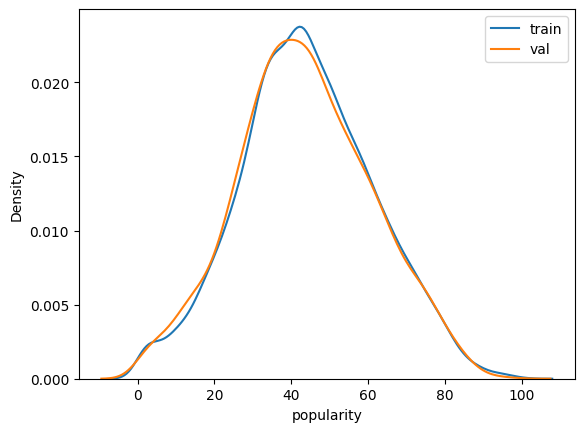

In [ ]:
## train and val sets have equal distributions
sns.kdeplot(y_train, label="train")
sns.kdeplot(y_val, label="val")
plt.legend()

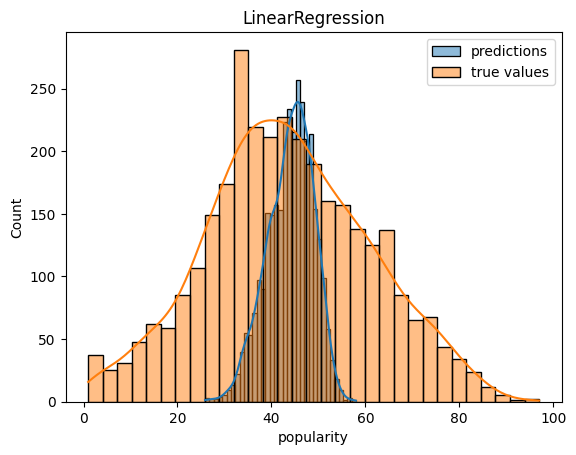

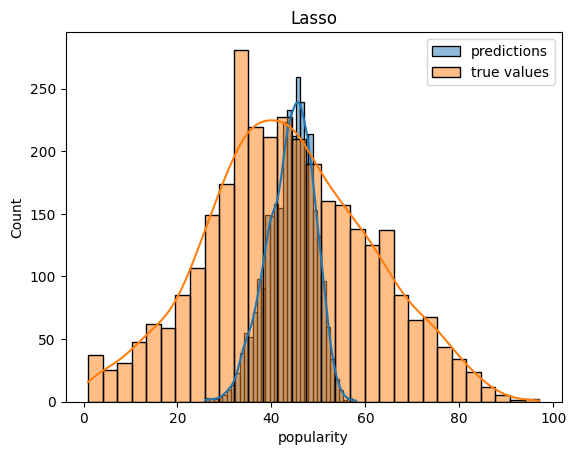

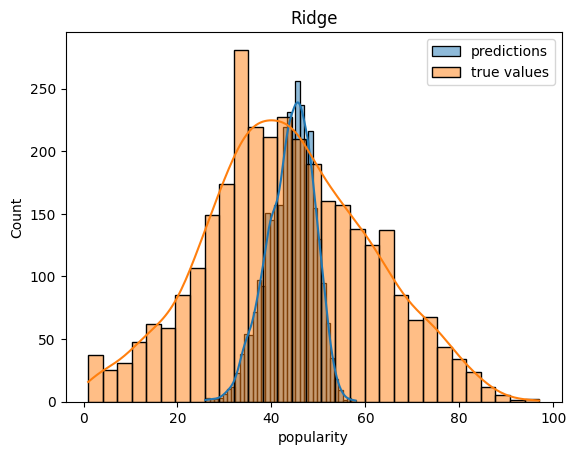

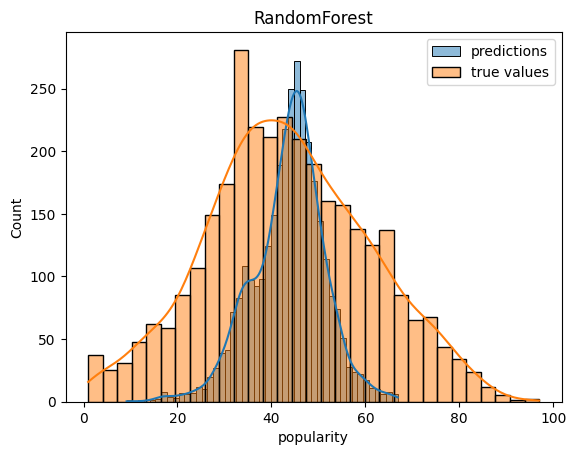

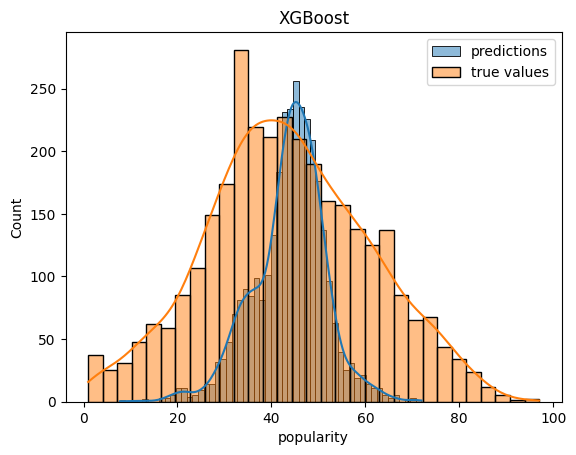

In [ ]:
## predicted value distribution is in around of mean
## of general distribution
for model in models:
    sns.histplot(preds[model], kde=True, label="predictions")
    sns.histplot(y_val, kde=True, label="true values")
    plt.title(model)
    plt.legend()
    plt.show();

In [ ]:
## baseline metrics value
root_mean_squared_error(y_val, [y_train.median()] * y_val.shape[0]),\
mean_absolute_error(y_val, [y_train.median()] * y_val.shape[0]),\
r2_score(y_val, [y_train.median()] * y_val.shape[0])

(17.478450071383797, 14.010088272383355, -0.0008736447158177452)

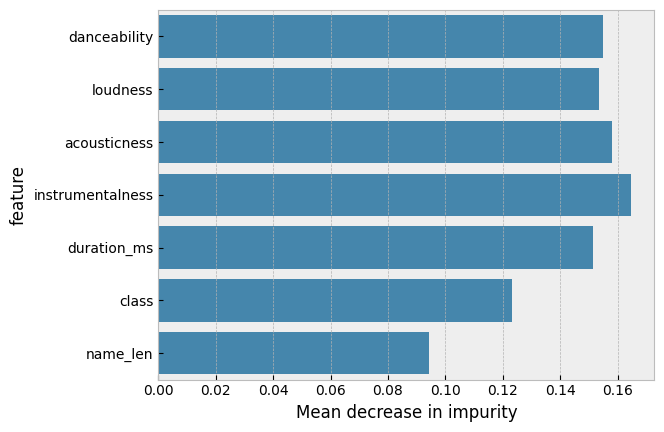

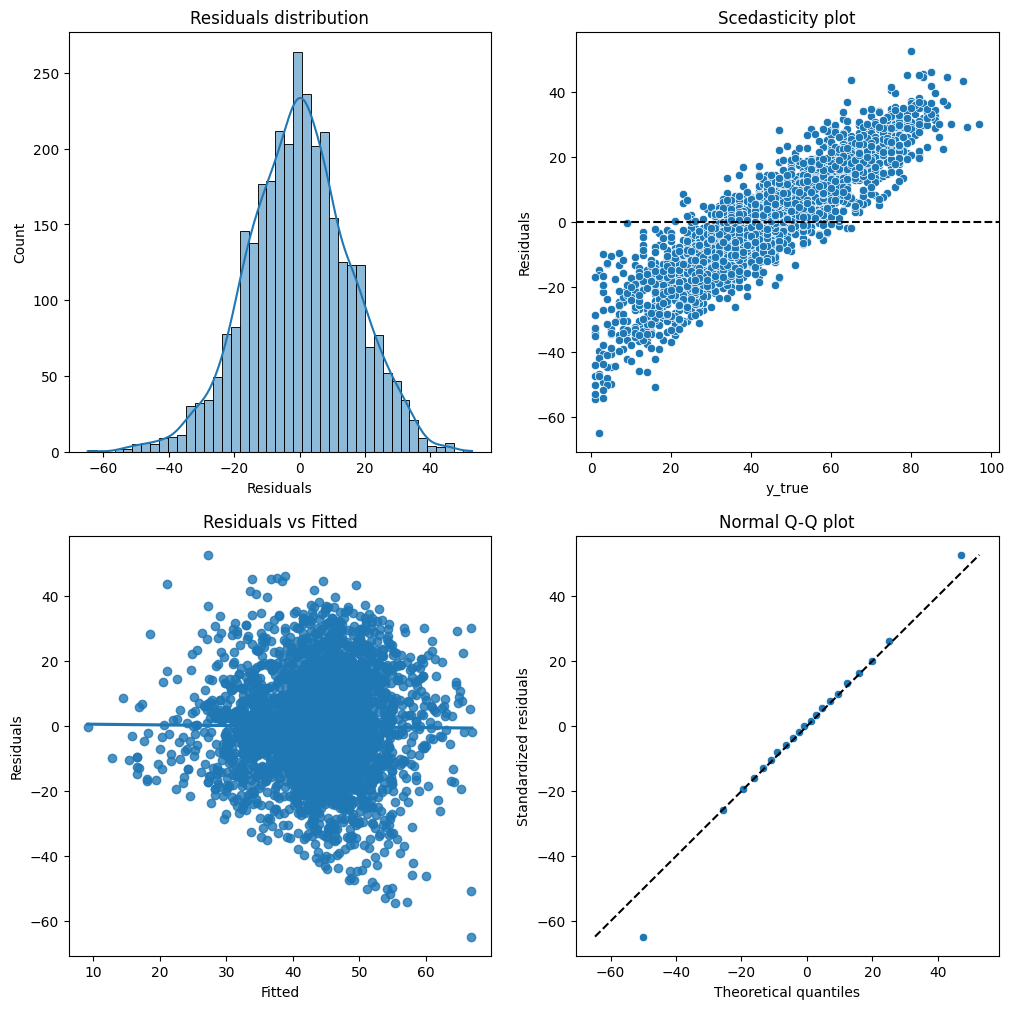

residuals skewness: -0.0926 (left)|equal to normal: False
residuals kurtosis: 0.1976 (upper)|equal to normal: False
[[  1.         -47.425     ]
 [  1.         -34.18666667]
 [  1.         -32.63666667]
 ...
 [ 93.          43.50666667]
 [ 94.          29.32      ]
 [ 97.          30.23333333]]
There is heteroscedasticity of residuals: True
std of each residuals bin [11.4669, 8.3293, 6.6687, 7.0988, 7.0074, 6.0806, 6.2623, 6.7541, 5.5249, 6.1008, 6.5471, 6.6966]


In [ ]:
## feature importances based on RandomForest
with plt.style.context("bmh"):
    sns.barplot(
        y=x_train.columns.to_list(),
        x=models["RandomForest"].estimator.feature_importances_,
        orient="y"
    )
    plt.yticks(
        np.arange(x_train.shape[1]), x_train.columns.to_list()
    )
    plt.ylabel("feature")
    plt.xlabel("Mean decrease in impurity");
error_plots(y_val, preds["RandomForest"])

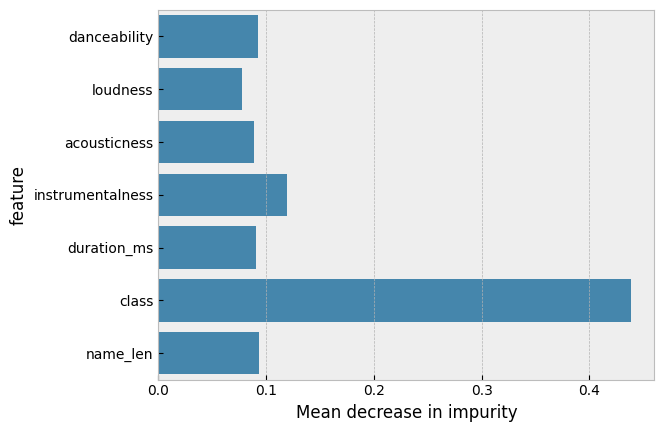

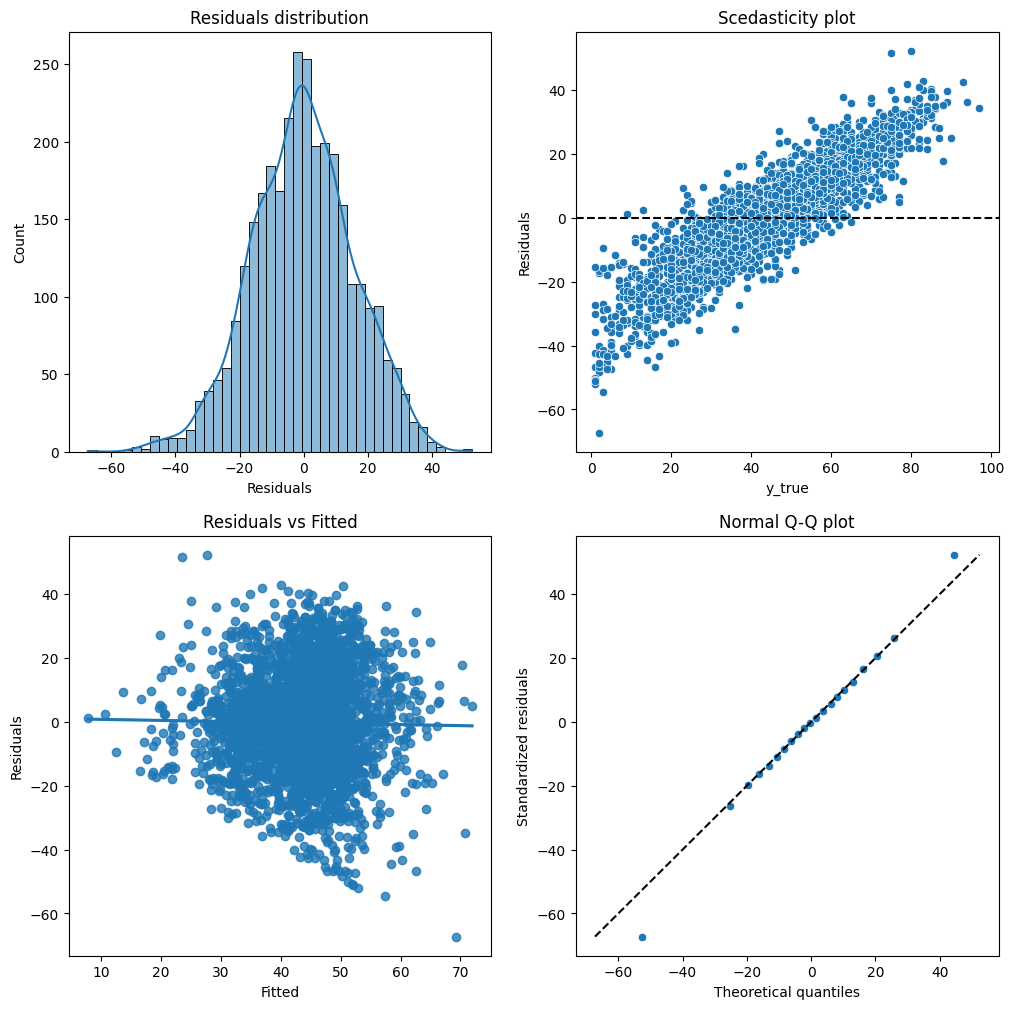

residuals skewness: -0.0949 (left)|equal to normal: False
residuals kurtosis: 0.0867 (upper)|equal to normal: True
[[  1.         -46.74047089]
 [  1.         -42.27268982]
 [  1.         -35.78341293]
 ...
 [ 93.          42.59563828]
 [ 94.          36.42681885]
 [ 97.          34.40576935]]
There is heteroscedasticity of residuals: True
std of each residuals bin [11.1182, 8.4242, 6.8516, 7.3744, 7.2579, 6.1517, 6.4798, 6.711, 5.8256, 6.0086, 6.2704, 6.3503]


In [ ]:
## feature importances based on XGBoost
with plt.style.context("bmh"):
    sns.barplot(
        y=x_train.columns.to_list(),
        x=models["XGBoost"].estimator.feature_importances_,
        orient="y"
    )
    plt.yticks(
        np.arange(x_train.shape[1]), x_train.columns.to_list()
    )
    plt.ylabel("feature")
    plt.xlabel("Mean decrease in impurity");
error_plots(y_val, preds["XGBoost"])

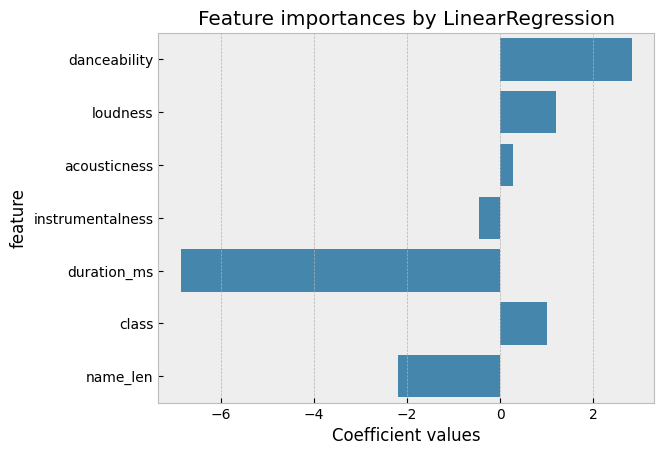

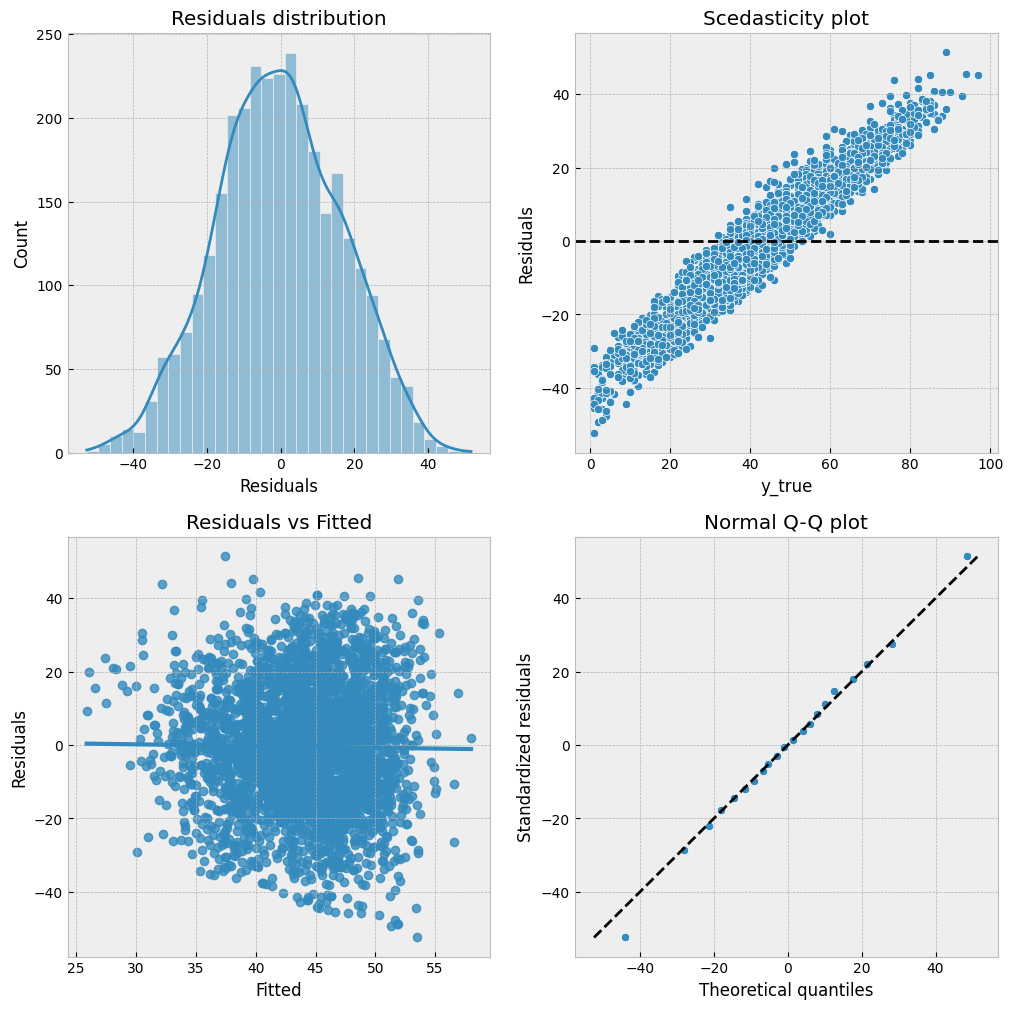

residuals skewness: -0.0175 (left)|equal to normal: True
residuals kurtosis: -0.3043 (lower)|equal to normal: False
[[  1.         -35.14271084]
 [  1.         -44.09941403]
 [  1.         -34.31159912]
 ...
 [ 93.          39.45559242]
 [ 94.          45.43852825]
 [ 97.          45.14528047]]
There is heteroscedasticity of residuals: True
std of each residuals bin [7.0747, 5.7236, 5.0945, 4.716, 5.0646, 4.9989, 5.0582, 5.0918, 4.9341, 4.9568, 4.58, 4.3964]


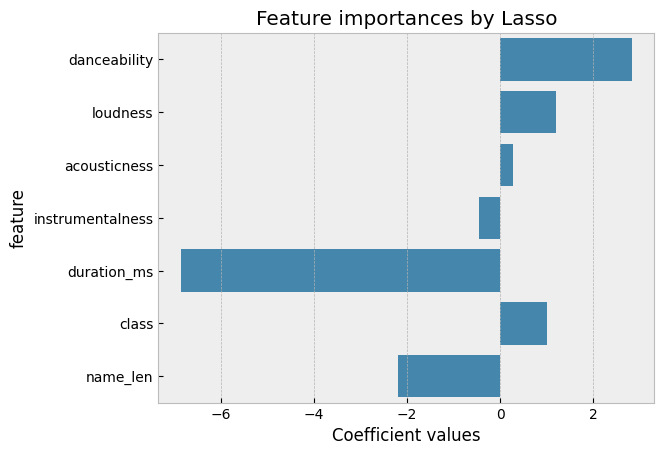

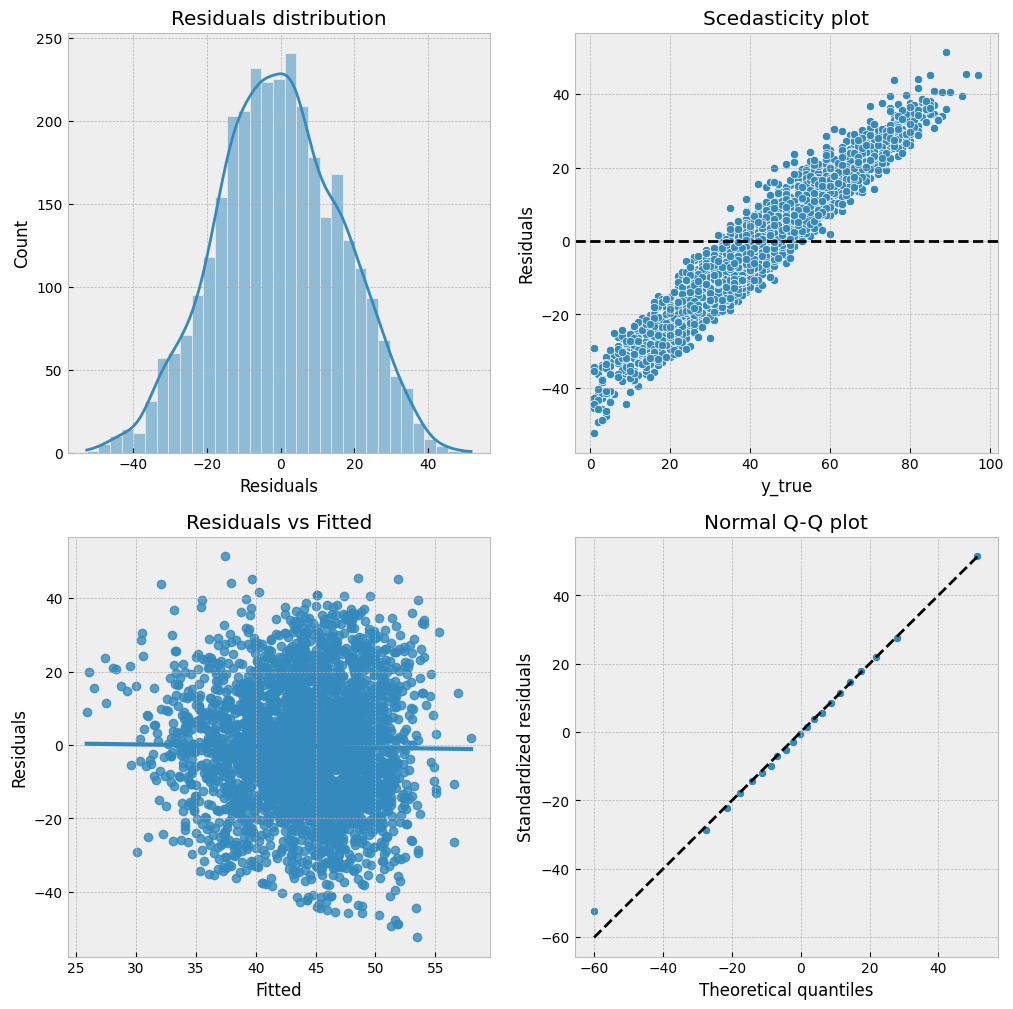

residuals skewness: -0.0173 (left)|equal to normal: True
residuals kurtosis: -0.3043 (lower)|equal to normal: False
[[  1.         -35.14110313]
 [  1.         -44.0969135 ]
 [  1.         -34.33367764]
 ...
 [ 93.          39.46005607]
 [ 94.          45.44695425]
 [ 97.          45.15667636]]
There is heteroscedasticity of residuals: True
std of each residuals bin [7.0707, 5.7211, 5.09, 4.712, 5.0614, 4.9951, 5.0568, 5.089, 4.9317, 4.9546, 4.5773, 4.394]


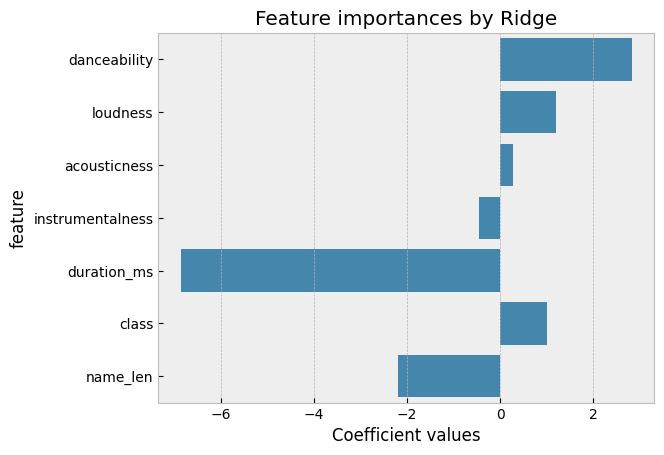

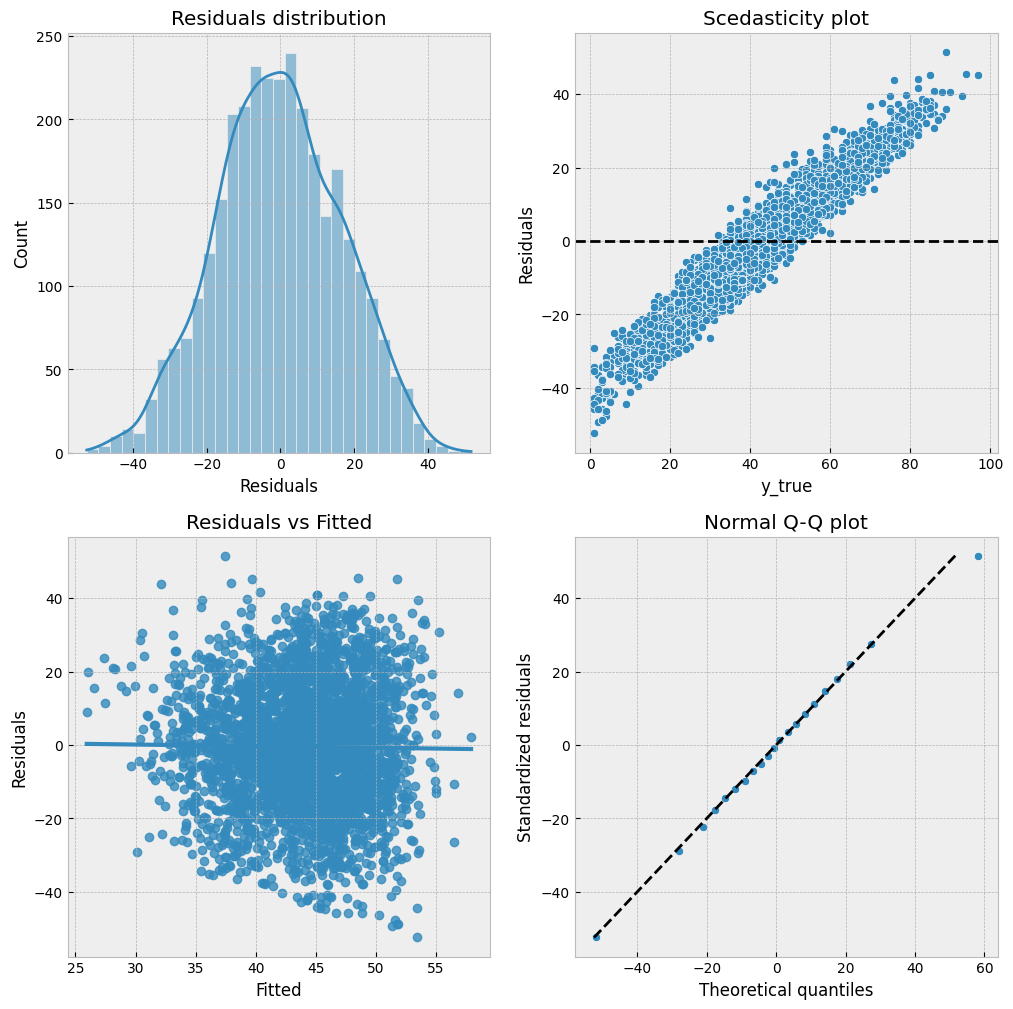

residuals skewness: -0.0170 (left)|equal to normal: True
residuals kurtosis: -0.3046 (lower)|equal to normal: False
[[  1.         -35.14061489]
 [  1.         -44.10556232]
 [  1.         -34.41095724]
 ...
 [ 93.          39.4680425 ]
 [ 94.          45.48119218]
 [ 97.          45.20434165]]
There is heteroscedasticity of residuals: True
std of each residuals bin [7.0588, 5.7187, 5.0802, 4.7016, 5.0556, 4.9873, 5.0554, 5.0841, 4.9291, 4.9496, 4.5734, 4.3874]


In [ ]:
## feature importances by linear regressions
with plt.style.context("bmh"):
    for name in ["LinearRegression", "Lasso", "Ridge"]:
        sns.barplot(
            y=x_train.columns.to_list(),
            x=models["LinearRegression"].estimator.coef_,
            orient="y"
        )
        plt.title(f"Feature importances by {name}")
        plt.yticks(
            np.arange(x_train.shape[1]), x_train.columns.to_list()
        )
        plt.ylabel("feature")
        plt.xlabel("Coefficient values")
        plt.show();
        error_plots(y_val, preds[name])

In [ ]:
## error distributions over models are mostly equal
stat_compare_distr(pd.DataFrame({key: y_val - p for key, p in preds.items()}))

There are any difference: True
LinearRegression > RandomForest
Lasso > RandomForest
Ridge > RandomForest
RandomForest < XGBoost


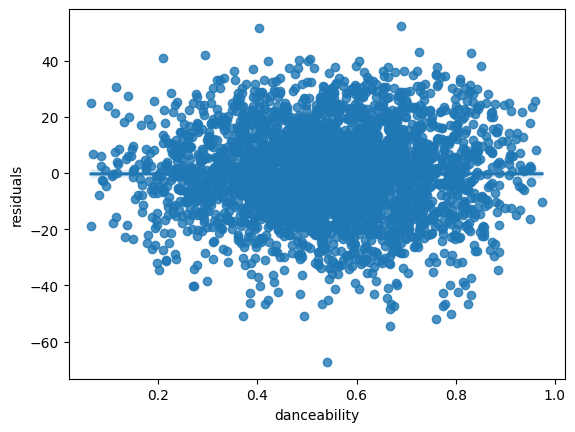

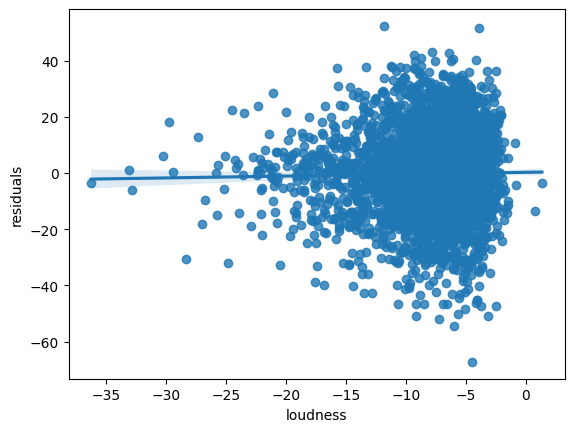

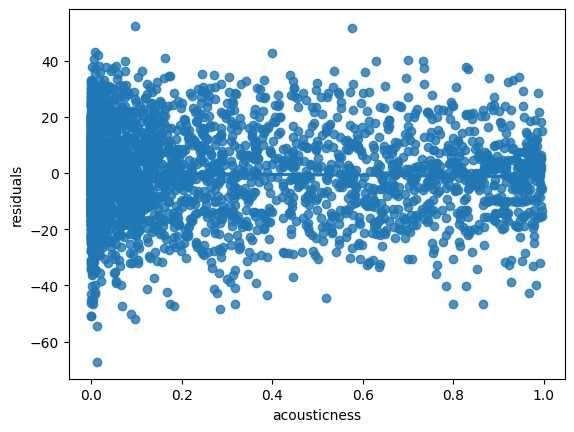

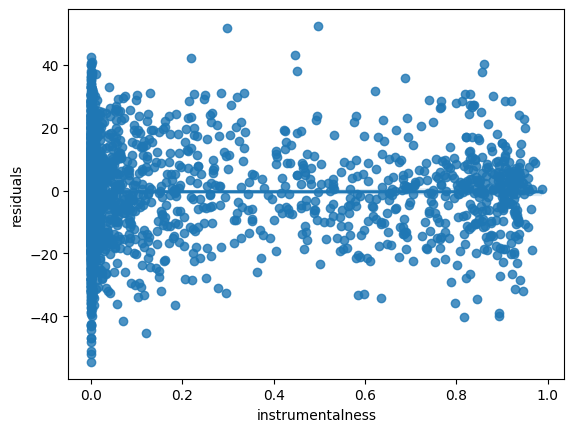

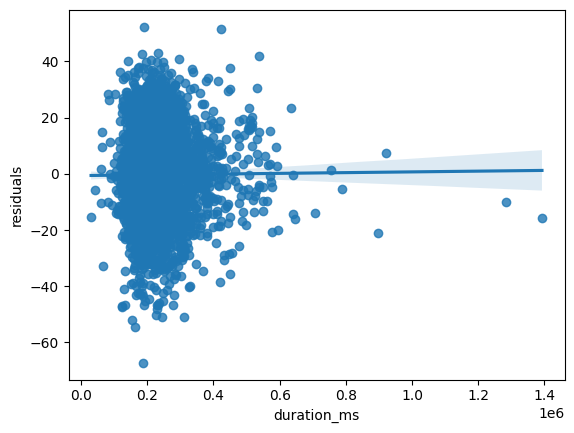

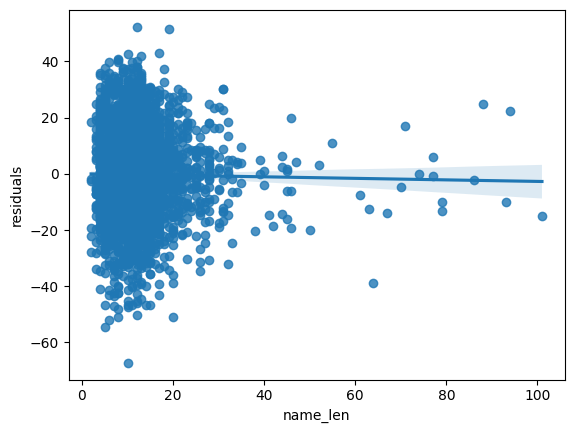

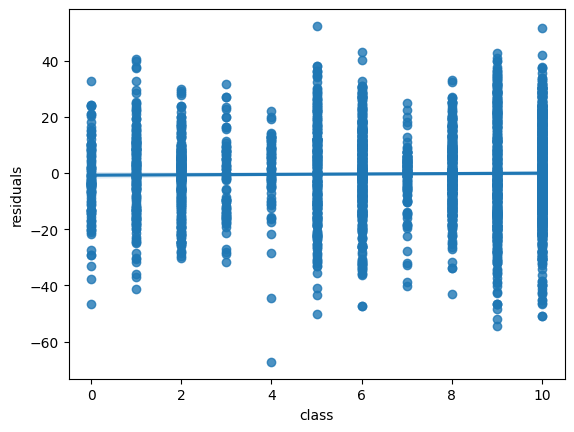

In [130]:
## there aren't any undefined dependences
res = pd.DataFrame(y_val - preds["XGBoost"])
res.columns = ["residuals"]
tmp = pd.concat([x_val, res], axis=1)
for col in numeric_cols + ["class"]:
    if col == "class":
        sns.regplot(x=tmp[col].cat.as_ordered(), y=tmp["residuals"])
    else:
        sns.regplot(tmp, x=col, y="residuals")
    plt.show();

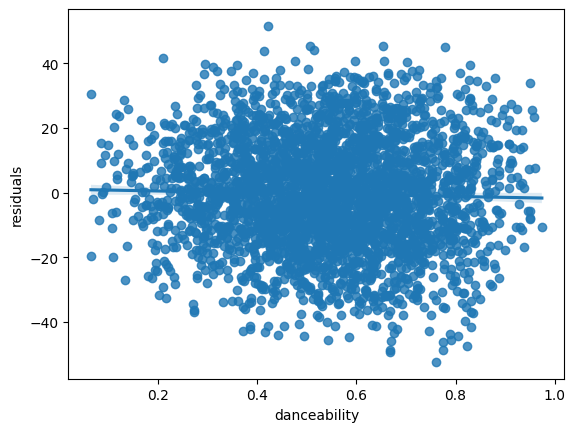

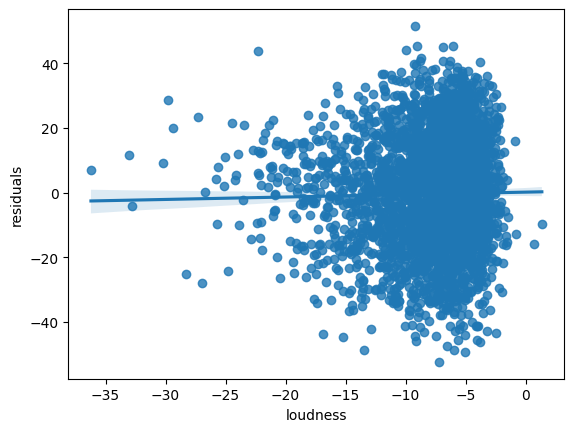

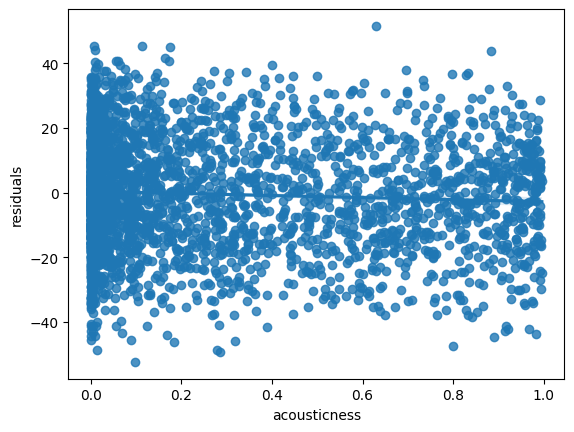

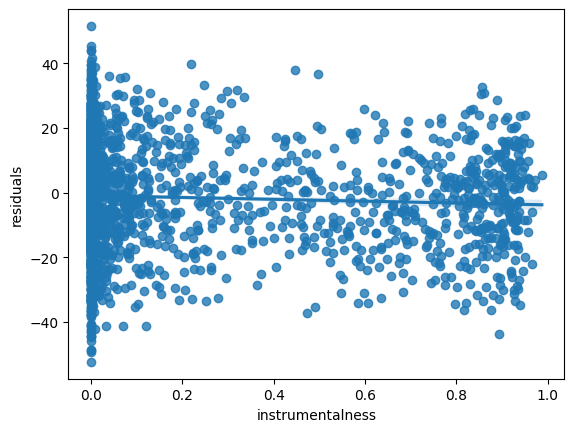

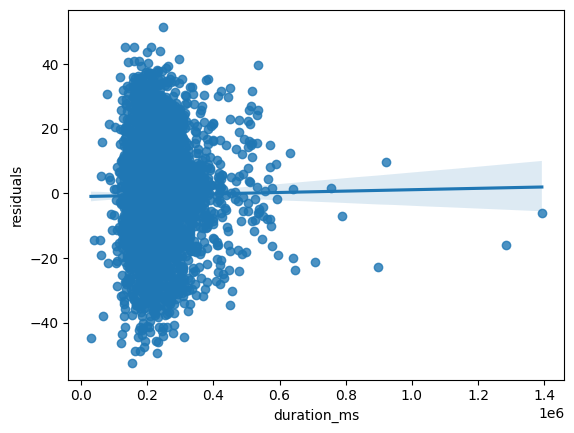

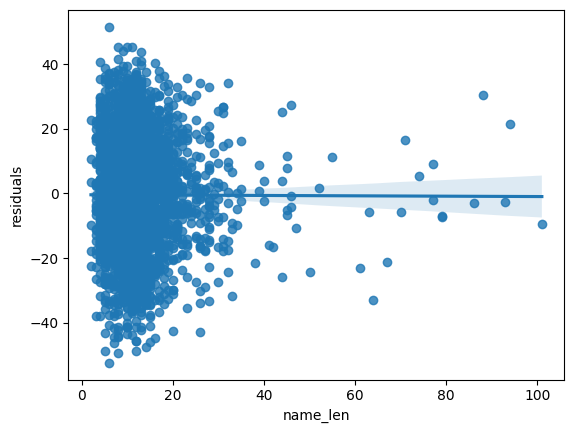

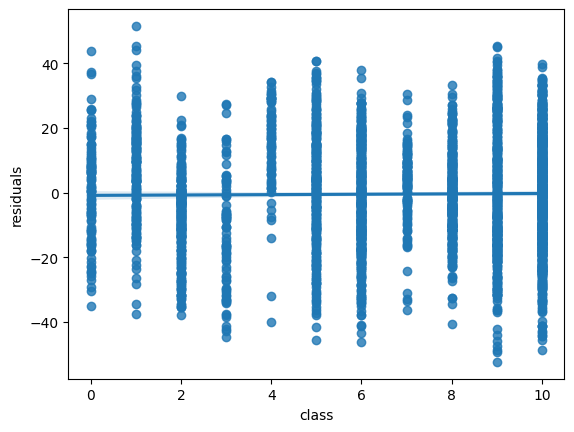

In [131]:
res = pd.DataFrame(y_val - preds["Ridge"])
res.columns = ["residuals"]
tmp = pd.concat([x_val, res], axis=1)
for col in numeric_cols + ["class"]:
    if col == "class":
        sns.regplot(x=tmp[col].cat.as_ordered(), y=tmp["residuals"])
    else:
        sns.regplot(tmp, x=col, y="residuals")
    plt.show();